# Ordinary least-squares identification

Baseline: least-squares fit of a fixed 8-term library on the training levels (500, 1000, 2000 and 2500 mg); the 1500 mg level is the test set.

## Imports


In [1]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

EXPERIMENTAL_COLOR = COLORS["brown"]
LEAST_SQUARES_COLOR = COLORS["purple"]

## Shared protocol and paths


In [2]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]


In [3]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder):
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, roles in record["model_predictions"].items()
                       for role, predicted in roles.items()]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k",
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

In [4]:
DIMENSIONLESS_ZERO_TOLERANCE = 0.001
RESULTS_DIR = PROJECT_ROOT / "results"
PREPARED_FILE = RESULTS_DIR / "prepared_signals.pkl"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "3_least_squares"
if not PREPARED_FILE.exists():
    raise FileNotFoundError("results/prepared_signals.pkl was not found. Run notebook 2 first.")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load trajectories


In [5]:
with PREPARED_FILE.open("rb") as file:
    prepared_data = pickle.load(file)
spectral_signals = prepared_data["spectral_signals"]
print("Number of spectral trajectories:", len(spectral_signals))
for index, signal in enumerate(spectral_signals):
    print(index, "-", signal["name"])


Number of spectral trajectories: 10
0 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down
1 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up
2 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down
3 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up
4 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down
5 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_up
6 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_down
7 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_up
8 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down
9 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up


## Train/test split


In [6]:
all_signals = check_signals(spectral_signals)
split = split_signals(all_signals)
split_summary = split_table(split)
display(split_summary)
usage_table = pd.DataFrame(
    [{"level_mg": excitation_level_mg(s["name"]), "sweep": sweep_direction(s["name"]),
      "samples": len(s["t"]), "duration_s": float(s["t"][-1] - s["t"][0]),
      "role": signal_role(s["name"]), "name": s["name"]} for s in all_signals]
)
display(usage_table)
print(f"Experiments: {len(all_signals)}; samples: {usage_table['samples'].sum():,}")

,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


,level_mg,sweep,samples,duration_s,role,name
0,500,down,401408,1003.5175,train,relative_acceleration_000mA_500mg_50-150_Hz_sw...
1,500,up,401408,1003.5175,train,relative_acceleration_000mA_500mg_50-150_Hz_sw...
2,1000,down,401377,1003.4400,train,relative_acceleration_000mA_1000mg_50-150_Hz_s...
3,1000,up,401376,1003.4375,train,relative_acceleration_000mA_1000mg_50-150_Hz_s...
4,1500,down,401377,1003.4400,test,relative_acceleration_000mA_1500mg_50-150_Hz_s...
5,1500,up,401376,1003.4375,test,relative_acceleration_000mA_1500mg_50-150_Hz_s...
6,2000,down,401408,1003.5175,train,relative_acceleration_000mA_2000mg_50-150_Hz_s...
7,2000,up,401408,1003.5175,train,relative_acceleration_000mA_2000mg_50-150_Hz_s...
8,2500,down,401377,1003.4400,train,relative_acceleration_000mA_2500mg_50-150_Hz_s...
9,2500,up,401376,1003.4375,train,relative_acceleration_000mA_2500mg_50-150_Hz_s...


Experiments: 10; samples: 4,013,891


## Library


In [7]:
TERM_NAMES = ["v", "v^2", "v^3", "x", "x^2", "x^3", "u", "v^4"]
TERM_UNITS = ["1/s", "1/m", "s/m^2", "1/s^2", "1/(m*s^2)", "1/(m^2*s^2)", "1", "s^2/m^3"]


def build_library(x, v, u):
    x, v, u = np.broadcast_arrays(
        np.asarray(x, dtype=float), np.asarray(v, dtype=float), np.asarray(u, dtype=float)
    )
    return np.stack([v, v**2, v**3, x, x**2, x**3, u, v**4], axis=-1)


def trajectory_arrays(signal):
    t = np.asarray(signal["t"], dtype=float)
    x = np.asarray(signal["x"], dtype=float)
    v = np.asarray(signal["v"], dtype=float)
    u = np.asarray(signal["u"], dtype=float).squeeze()
    a_relative = np.asarray(signal["v_dot"], dtype=float)
    return (t, x, v, u, a_relative)


experiment_data = {}
for signal in all_signals:
    t, x, v, u, a_relative = trajectory_arrays(signal)
    experiment_data[signal["name"]] = {"Phi": build_library(x, v, u), "y": a_relative}


def stacked(signals):
    Phi = np.vstack([experiment_data[s["name"]]["Phi"] for s in signals])
    y = np.concatenate([experiment_data[s["name"]]["y"] for s in signals])
    return Phi, y


print("Library:", TERM_NAMES)
n_fit = sum(len(experiment_data[s["name"]]["y"]) for s in split["fit"])
n_test = sum(len(experiment_data[s["name"]]["y"]) for s in split["test"])
print(f"Training levels {split['fit_levels_mg']} mg: {n_fit:,} samples; "
      f"test level {split['test_level_mg']} mg: {n_test:,} samples")

Library: ['v', 'v^2', 'v^3', 'x', 'x^2', 'x^3', 'u', 'v^4']
Training levels (500, 1000, 2000, 2500) mg: 3,211,138 samples; test level 1500 mg: 802,753 samples


## Least-squares fits


In [8]:
def fit_least_squares(signals):
    Phi, y = stacked(signals)
    column_scale = np.sqrt(np.mean(Phi**2, axis=0))
    column_scale[column_scale == 0.0] = 1.0
    coefficients_scaled, _, rank, singular_values = np.linalg.lstsq(Phi / column_scale, y, rcond=None)
    return {
        "coefficients": coefficients_scaled / column_scale,
        "rank": int(rank),
        "condition_number": float(singular_values[0] / singular_values[-1]),
        "column_scale": column_scale,
        "samples": len(y),
    }


fit = fit_least_squares(split["fit"])
coefficients = fit["coefficients"]
coefficient_table = pd.DataFrame({"term": TERM_NAMES, "coefficient_unit": TERM_UNITS, "coefficient": coefficients})
display(coefficient_table)
print(f"Rank {fit['rank']}/{len(TERM_NAMES)}, condition number {fit['condition_number']:.6e}, "
      f"training samples {fit['samples']:,}")
print(f"\nIdentified equation (training levels {split['fit_levels_mg']} mg):\n")
print("a_rel = " + " + ".join(f"({value:+.8e}) {term}" for term, value in zip(TERM_NAMES, coefficients)))

,term,coefficient_unit,coefficient
0,v,1/s,-2.796839e+01
1,v^2,1/m,-3.220976e+01
2,v^3,s/m^2,-1.988714e+01
3,x,1/s^2,-3.537690e+05
4,x^2,1/(m*s^2),1.482645e+07
5,x^3,1/(m^2*s^2),2.058885e+10
6,u,1,-1.057269e+00
7,v^4,s^2/m^3,-3.734152e+01


Rank 8/8, condition number 5.324117e+00, training samples 3,211,138

Identified equation (training levels (500, 1000, 2000, 2500) mg):

a_rel = (-2.79683938e+01) v + (-3.22097607e+01) v^2 + (-1.98871351e+01) v^3 + (-3.53768961e+05) x + (+1.48264456e+07) x^2 + (+2.05888466e+10) x^3 + (-1.05726949e+00) u + (-3.73415236e+01) v^4


In [9]:
def model_acceleration(x, v, u, theta=None):
    if theta is None:
        theta = coefficients
    return build_library(x, v, u) @ theta


def regression_metrics(measured, predicted):
    measured = np.asarray(measured, dtype=float).ravel()
    predicted = np.asarray(predicted, dtype=float).ravel()
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual**2))
    standard_deviation = np.std(measured)
    nrmse = rmse / standard_deviation if standard_deviation > 0 else np.nan
    denominator = np.sum((measured - np.mean(measured)) ** 2)
    r2 = 1.0 - np.sum(residual**2) / denominator if denominator > 0 else np.nan
    return {"RMSE": rmse, "NRMSE": nrmse, "NRMSE_percent": 100.0 * nrmse, "R2": r2}

## Predictions at measured states


In [10]:
predicted_acceleration = {}
for signal in all_signals:
    predicted_acceleration[signal["name"]] = experiment_data[signal["name"]]["Phi"] @ coefficients


def pooled_arrays(signals):
    y = np.concatenate([experiment_data[s["name"]]["y"] for s in signals])
    p = np.concatenate([predicted_acceleration[s["name"]] for s in signals])
    return y, p


y_train, p_train = pooled_arrays(split["fit"])
y_test, p_test = pooled_arrays(split["test"])
metrics_table = pd.DataFrame([
    {"split": "train", "levels_mg": split["fit_levels_mg"], "samples": len(y_train),
     **regression_metrics(y_train, p_train)},
    {"split": "test", "levels_mg": (split["test_level_mg"],), "samples": len(y_test),
     **regression_metrics(y_test, p_test)},
])
display(metrics_table)

,split,levels_mg,samples,RMSE,NRMSE,NRMSE_percent,R2
0,train,"(500, 1000, 2000, 2500)",3211138,1.468316,0.022806,2.280623,0.999480
1,test,"(1500,)",802753,1.464331,0.024961,2.496096,0.999377


### Per-experiment metrics


In [11]:
per_signal_rows = []
for signal in all_signals:
    y = experiment_data[signal["name"]]["y"]
    per_signal_rows.append(
        {"role": signal_role(signal["name"]), "name": signal["name"], "level_mg": excitation_level_mg(signal["name"]),
         "sweep": sweep_direction(signal["name"]), "samples": len(y),
         **regression_metrics(y, predicted_acceleration[signal["name"]])}
    )
per_signal_equation_metrics = pd.DataFrame(per_signal_rows).sort_values(["role", "level_mg", "sweep"])
display(per_signal_equation_metrics)

,role,name,level_mg,sweep,samples,RMSE,NRMSE,NRMSE_percent,R2
4,test,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,401377,1.374544,0.022897,2.289654,0.999476
5,test,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,up,401376,1.548921,0.027049,2.704870,0.999268
0,train,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,401408,0.521702,0.024242,2.424248,0.999412
1,train,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,401408,0.531031,0.025560,2.556022,0.999347
2,train,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,401377,0.808973,0.020286,2.028639,0.999588
3,train,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,401376,0.716469,0.018688,1.868753,0.999651
6,train,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,down,401408,1.801137,0.023200,2.320015,0.999462
7,train,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,up,401408,1.986976,0.026633,2.663336,0.999291
8,train,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,down,401377,2.028737,0.021671,2.167098,0.999530
9,train,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,up,401376,2.053728,0.021832,2.183195,0.999523


### Parity plots


C:\Users\bruno\AppData\Local\Temp\ipykernel_25596\993814505.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(FIGURES_DIR / filename, format="pdf")
c:\Users\bruno\Downloads\BEPE (2)\BEPE\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


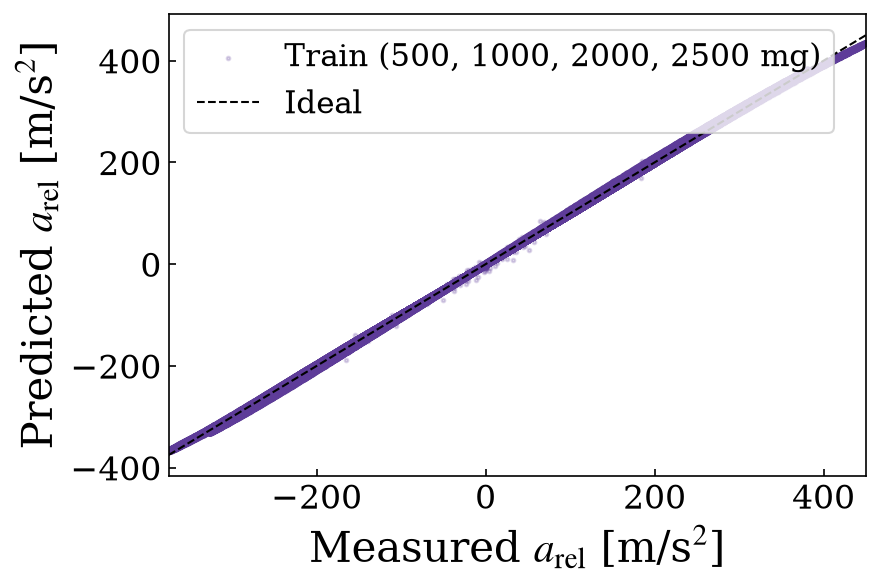

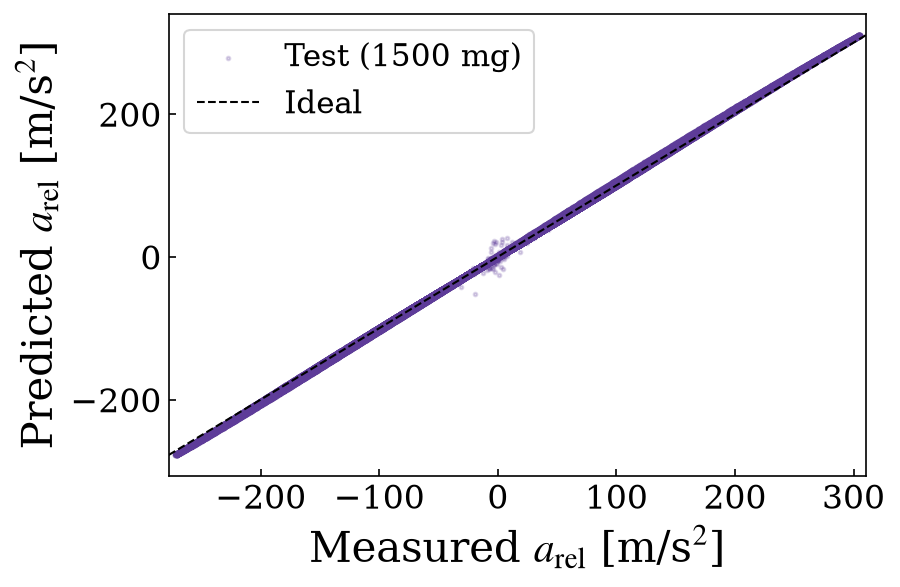

In [12]:
parity_data = [
    (y_train, p_train, f"Train ({', '.join(str(l) for l in split['fit_levels_mg'])} mg)", "least_squares_train_parity.pdf"),
    (y_test, p_test, f"Test ({split['test_level_mg']} mg)", "least_squares_test_parity.pdf"),
]
for measured, predicted, label, filename in parity_data:
    lower = min(np.min(measured), np.min(predicted))
    upper = max(np.max(measured), np.max(predicted))
    fig, ax = plt.subplots()
    ax.scatter(measured, predicted, s=3, alpha=0.2, rasterized=True, label=label)
    ax.plot([lower, upper], [lower, upper], color="k", linestyle="--", linewidth=1.0, label="Ideal")
    ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
    ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
    ax.legend()
    fig.savefig(FIGURES_DIR / filename, format="pdf")
    plt.show()

### Predicted trajectories


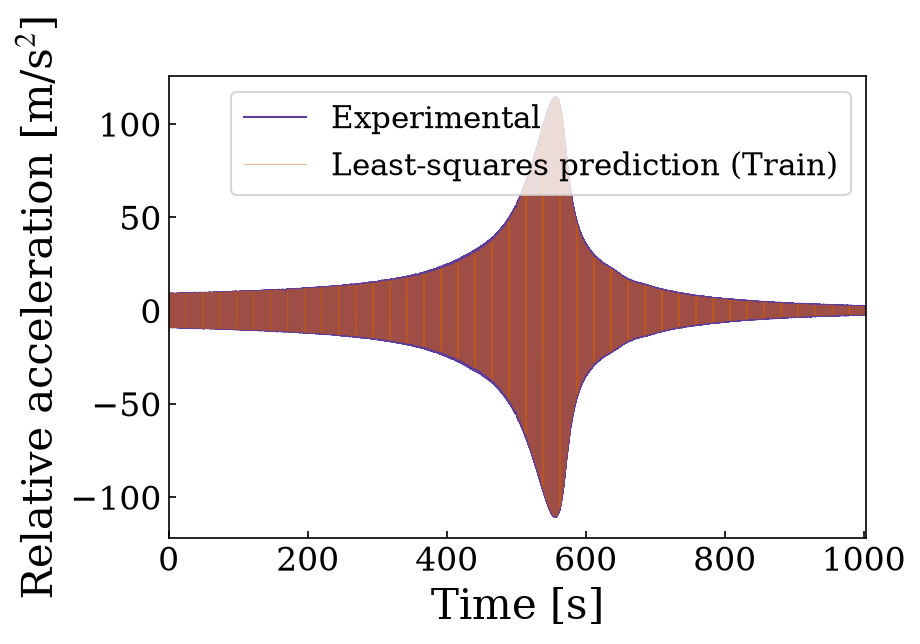

relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down | Train NRMSE = 2.4242% | R² = 0.99941230


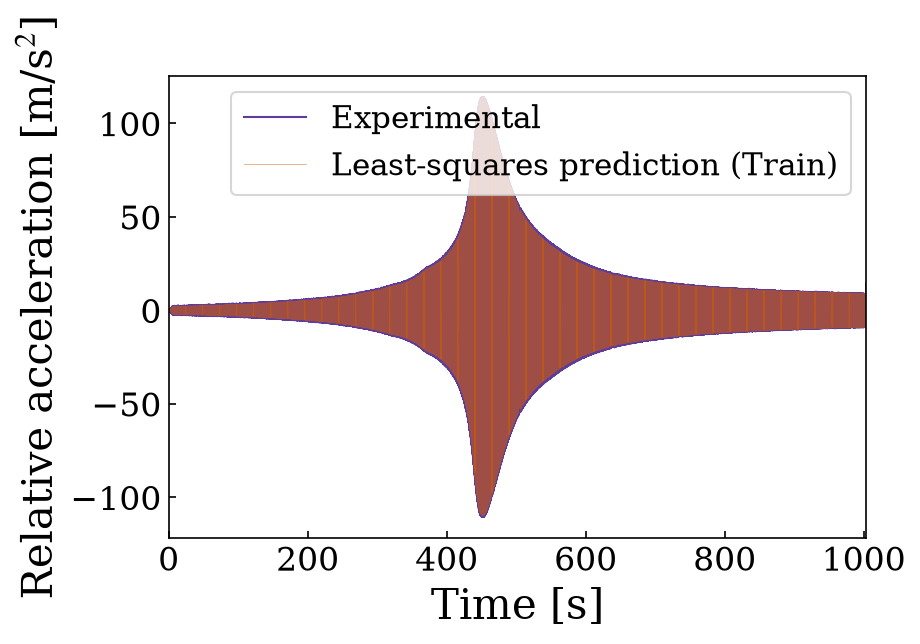

relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up | Train NRMSE = 2.5560% | R² = 0.99934668


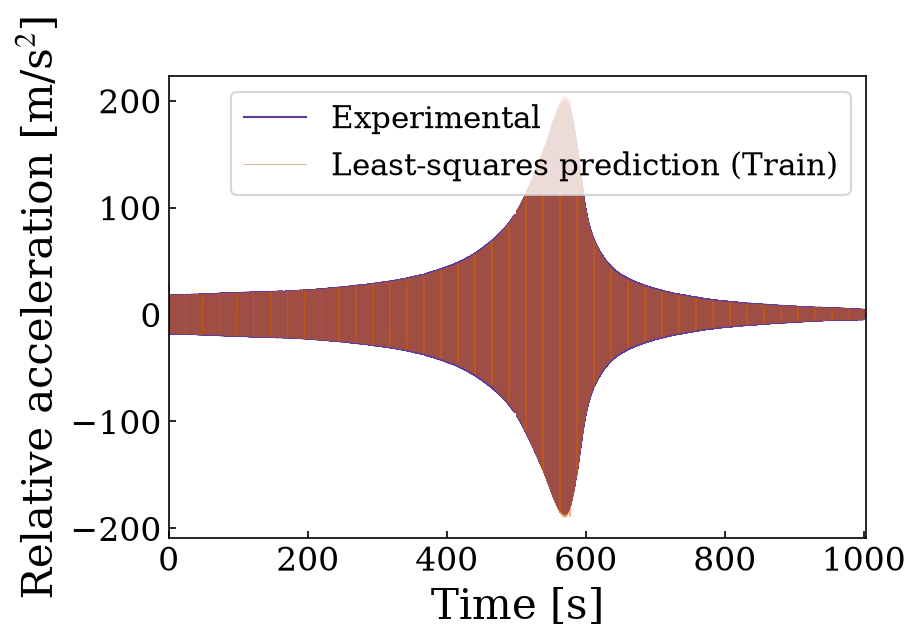

relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down | Train NRMSE = 2.0286% | R² = 0.99958846


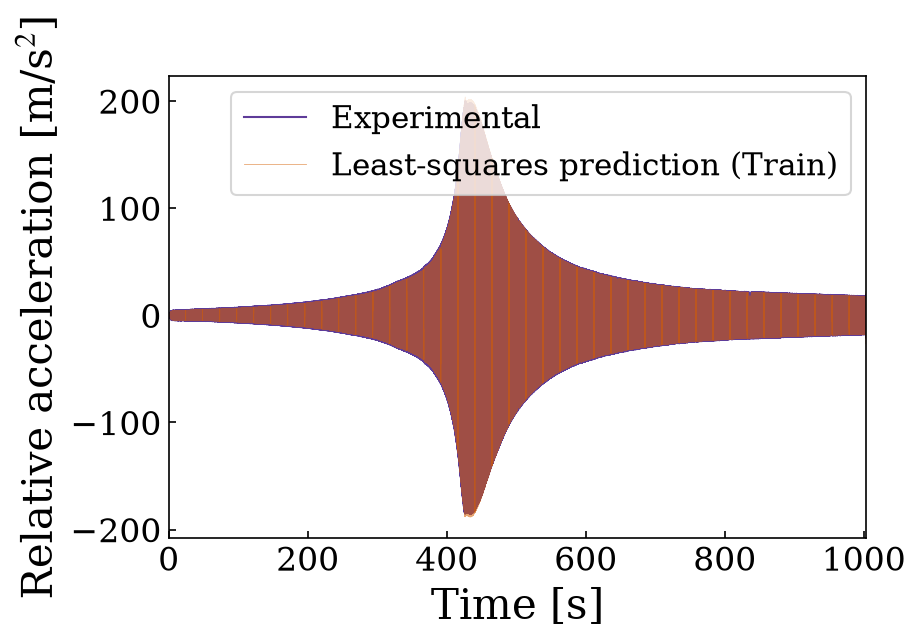

relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up | Train NRMSE = 1.8688% | R² = 0.99965078


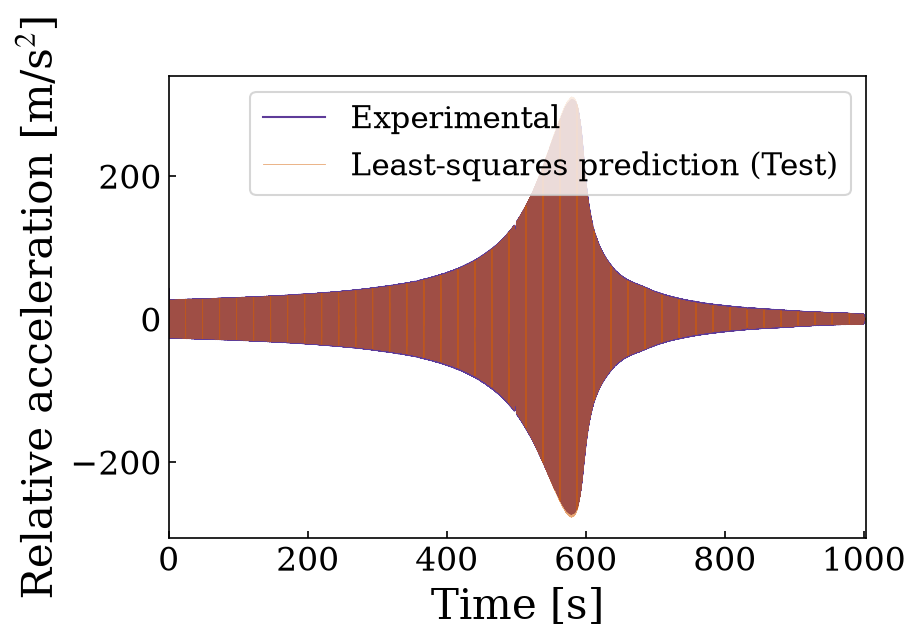

relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down | Test NRMSE = 2.2897% | R² = 0.99947575


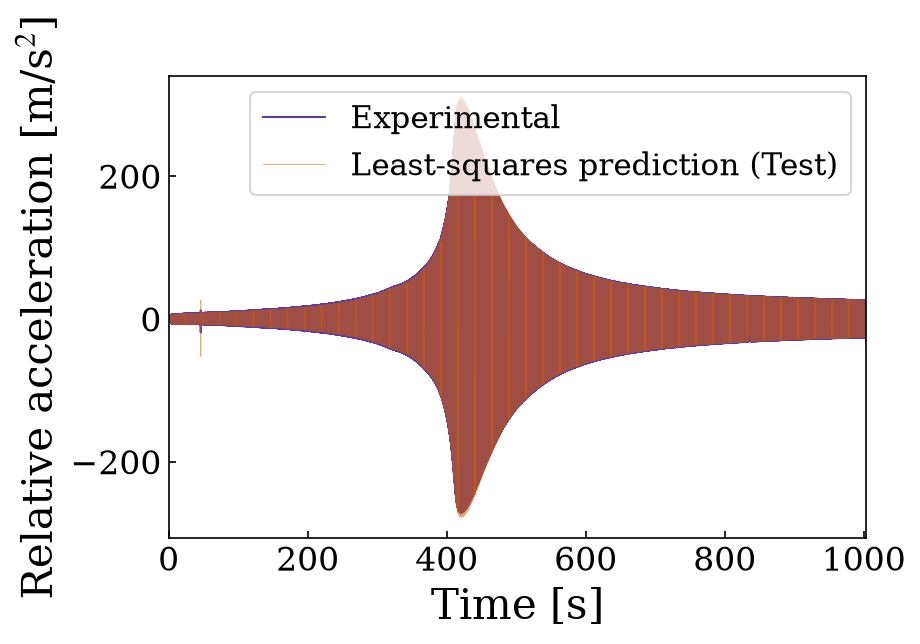

relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up | Test NRMSE = 2.7049% | R² = 0.99926837


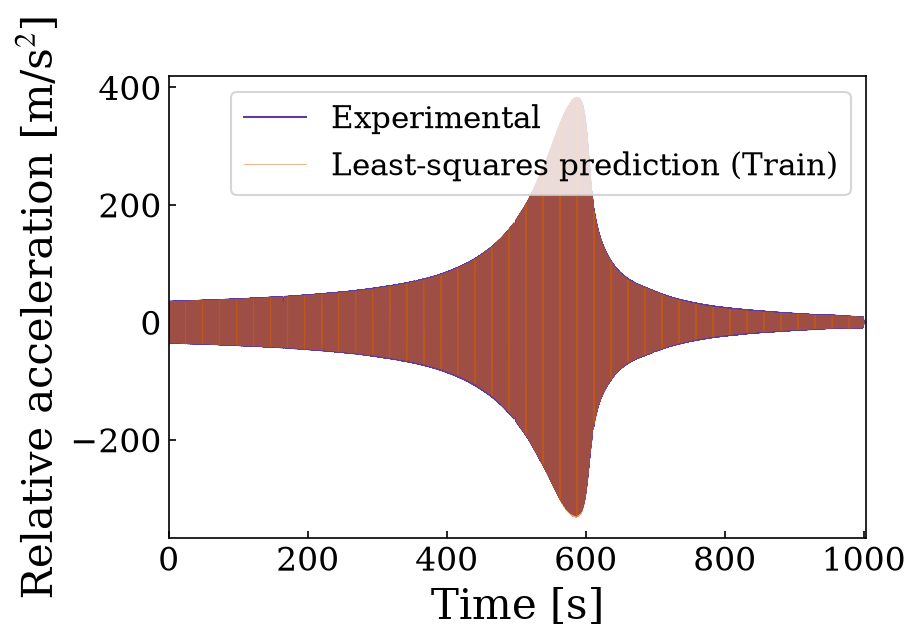

relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down | Train NRMSE = 2.3200% | R² = 0.99946175


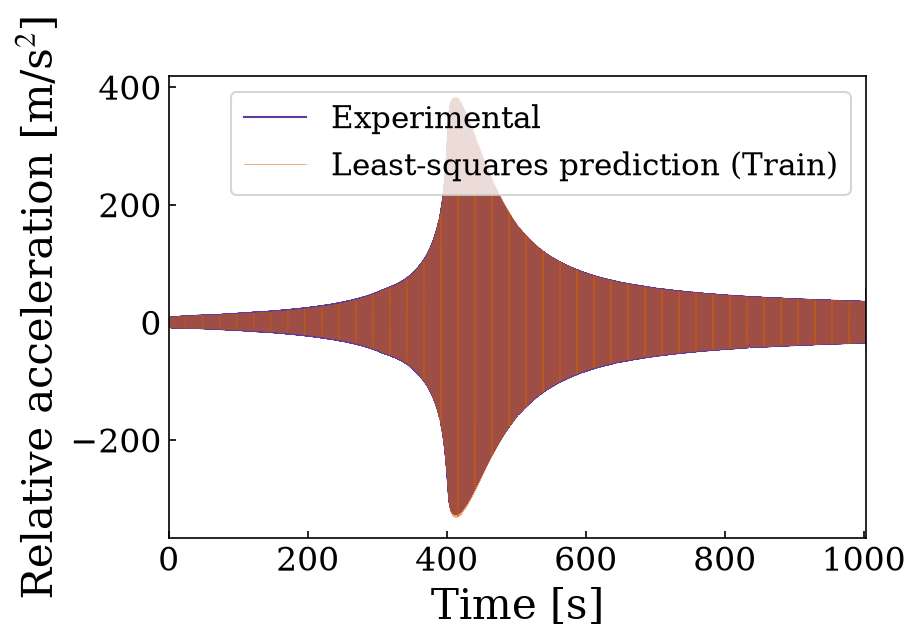

relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_up | Train NRMSE = 2.6633% | R² = 0.99929066


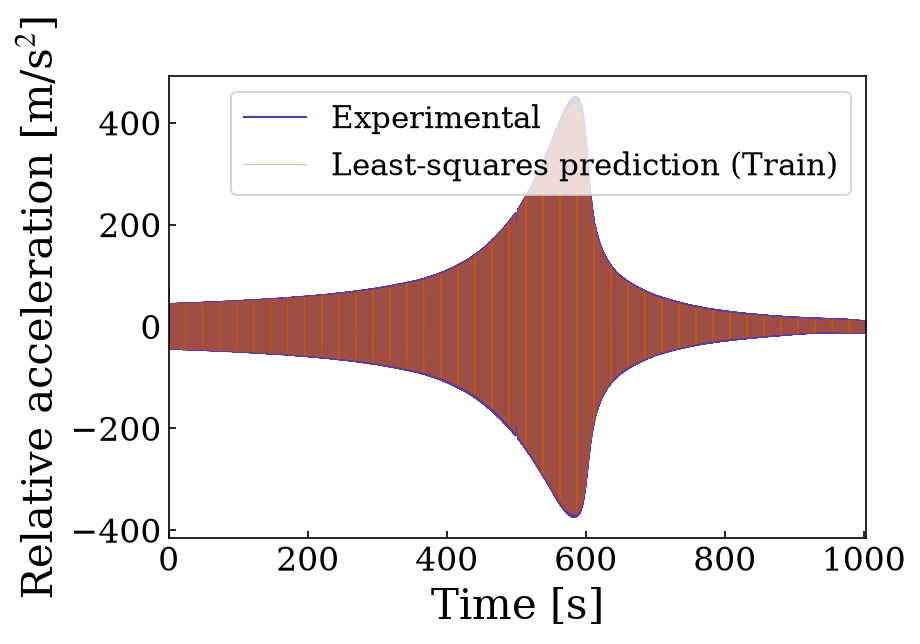

relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_down | Train NRMSE = 2.1671% | R² = 0.99953037


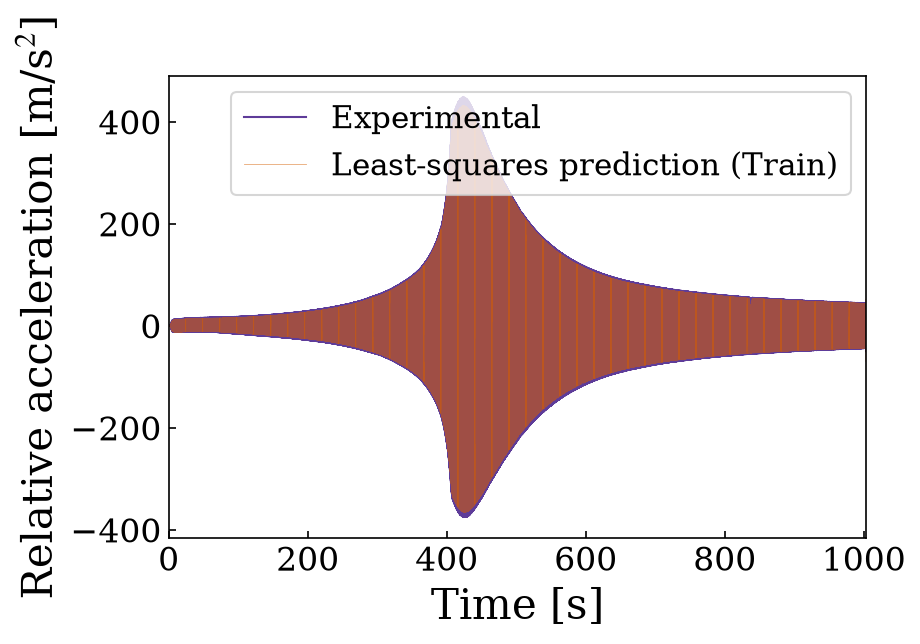

relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_up | Train NRMSE = 2.1832% | R² = 0.99952337


In [13]:
for signal in all_signals:
    t, x, v, u, a_measured = trajectory_arrays(signal)
    a_predicted = predicted_acceleration[signal["name"]]
    role_label = ROLE_LABELS[signal_role(signal["name"])]
    metrics = regression_metrics(a_measured, a_predicted)
    relative_time = t - t[0]
    fig, ax = plt.subplots()
    ax.plot(relative_time, a_measured, label="Experimental", linewidth=1.0)
    ax.plot(relative_time, a_predicted, label=f"Least-squares prediction ({role_label})", linewidth=0.4, alpha=0.55)
    ax.set_xlim(0.0, relative_time[-1])
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Relative acceleration [m/s$^2$]")
    ax.legend()
    fig.savefig(FIGURES_DIR / f"least_squares_equation_prediction_{slug(signal['name'])}.pdf", format="pdf")
    plt.show()
    plt.close(fig)
    print(signal["name"], f"| {role_label} NRMSE =", f"{metrics['NRMSE_percent']:.4f}%", "| R² =", f"{metrics['R2']:.8f}")

### Residual versus velocity


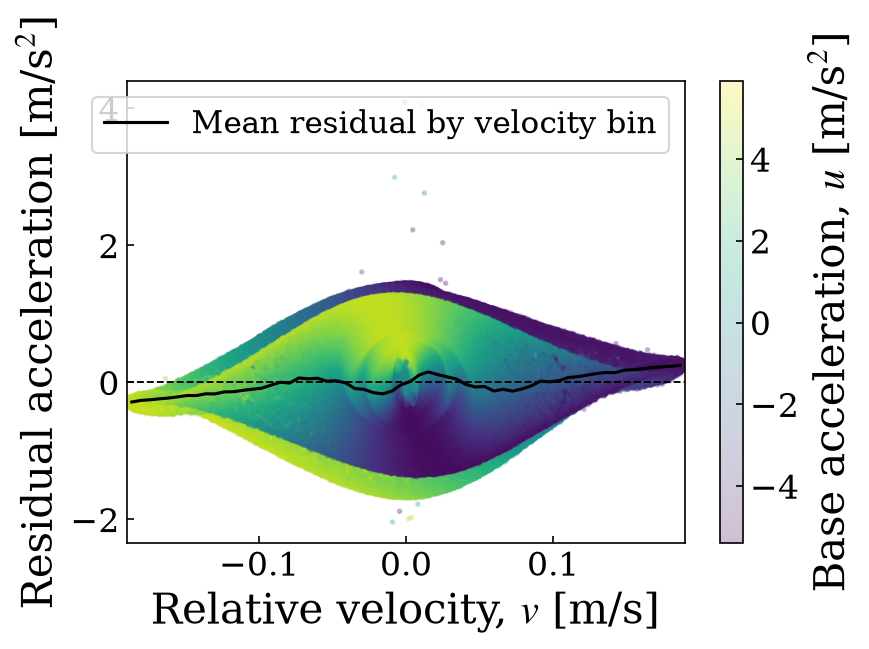

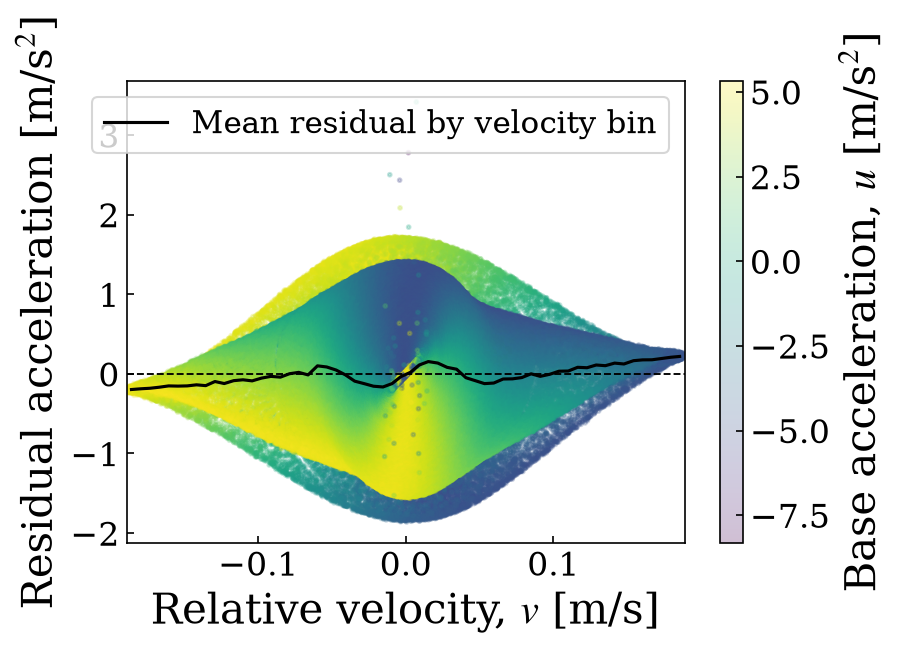

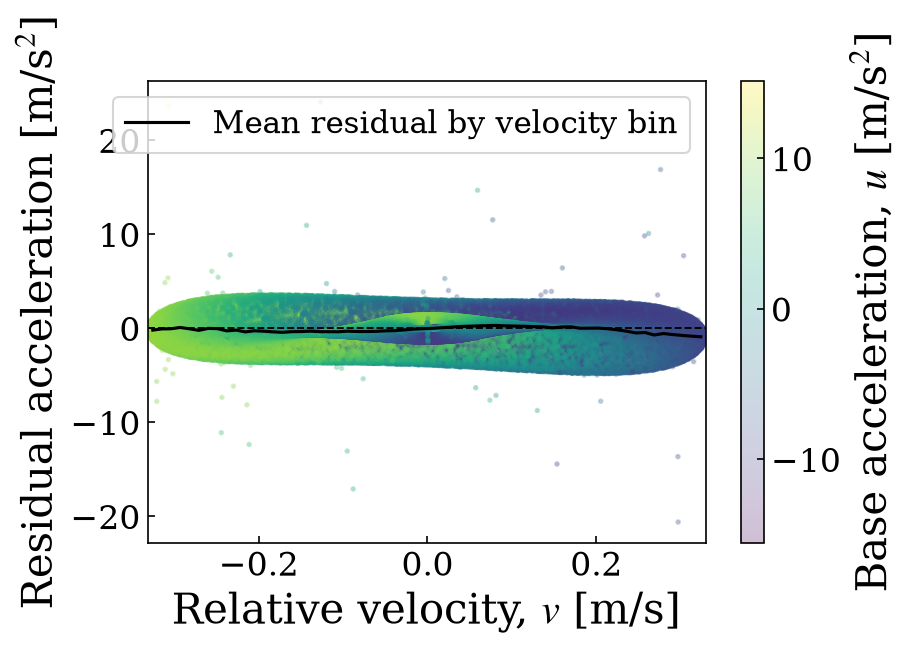

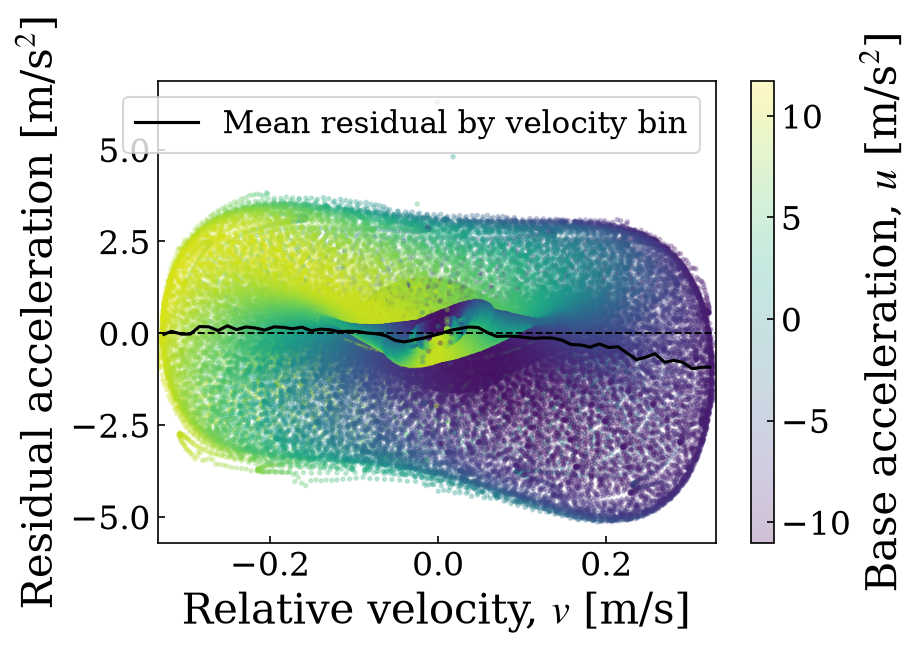

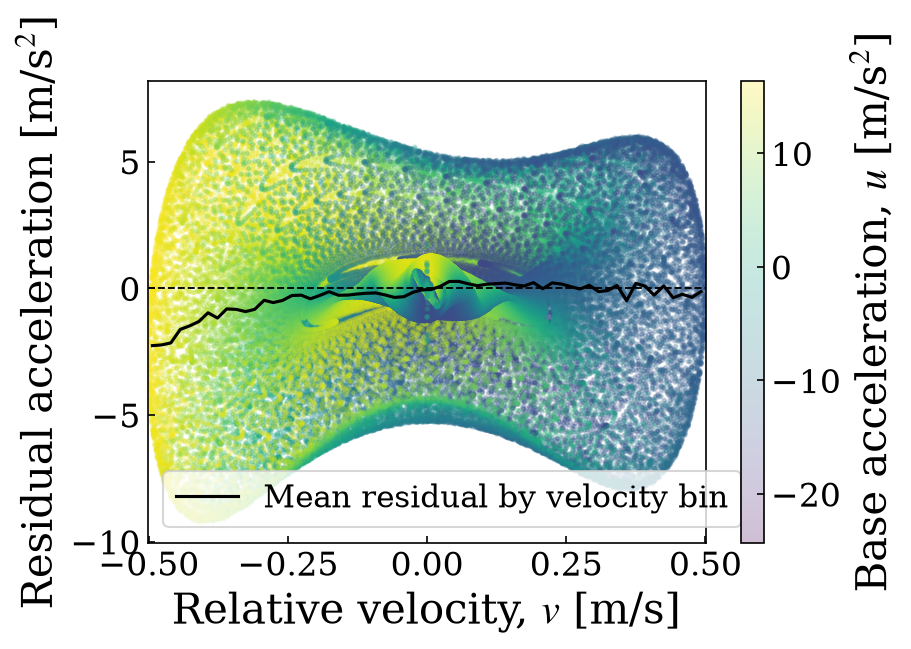

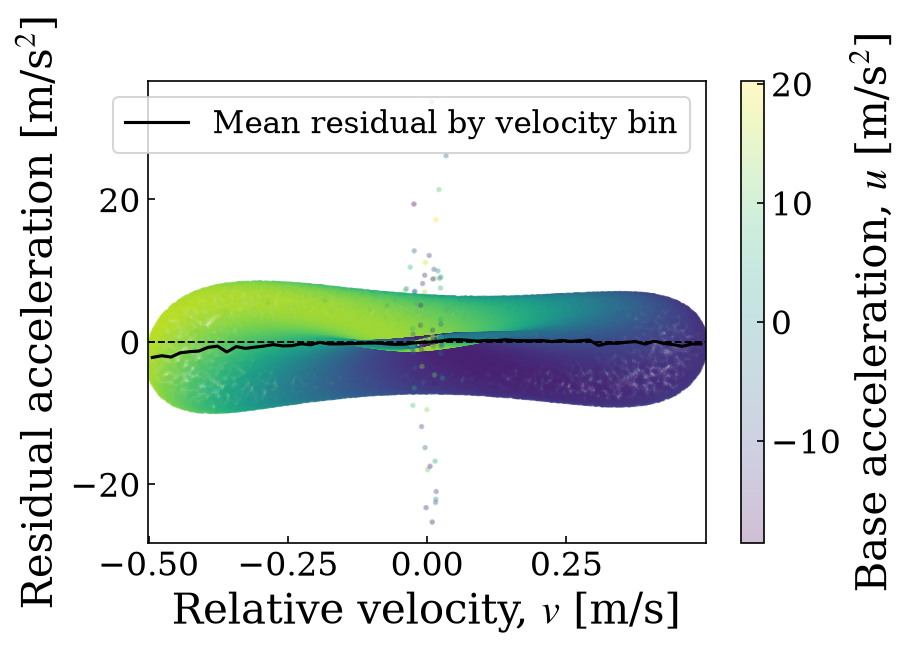

C:\Users\bruno\AppData\Local\Temp\ipykernel_25596\3138025622.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(FIGURES_DIR / f"least_squares_residual_vs_velocity_colored_u_{slug(signal['name'])}.pdf", format="pdf")


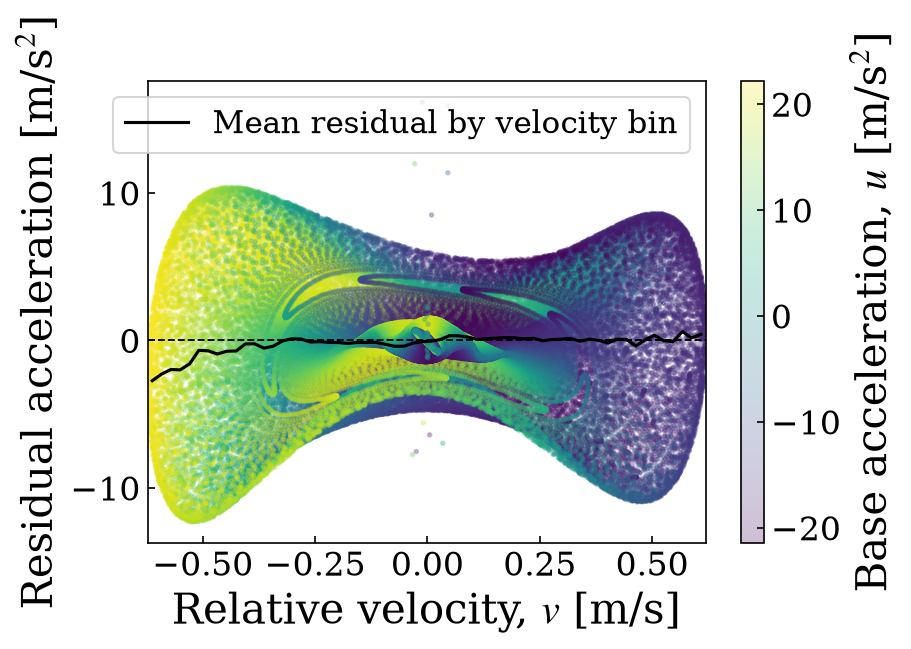

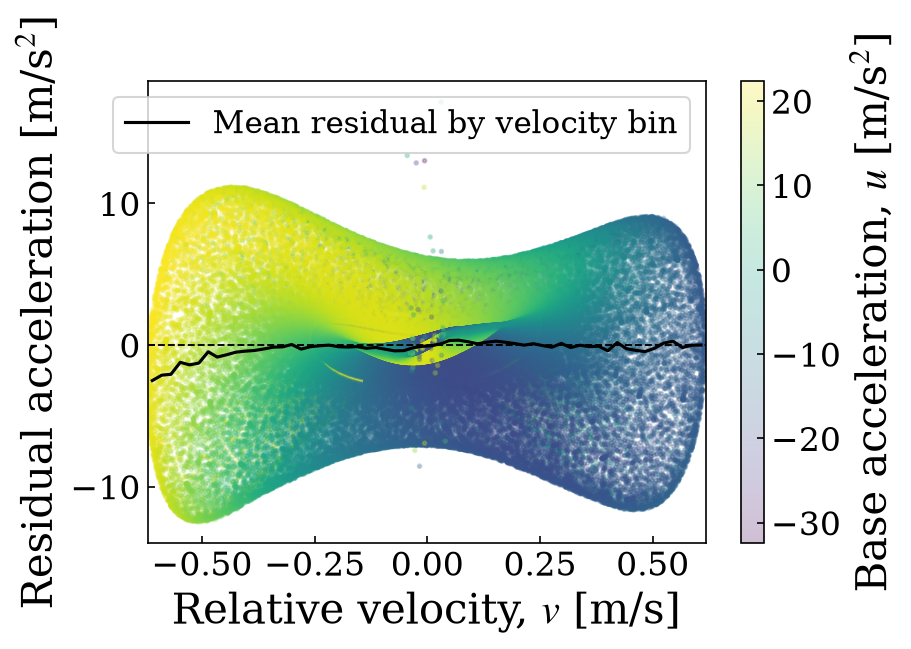

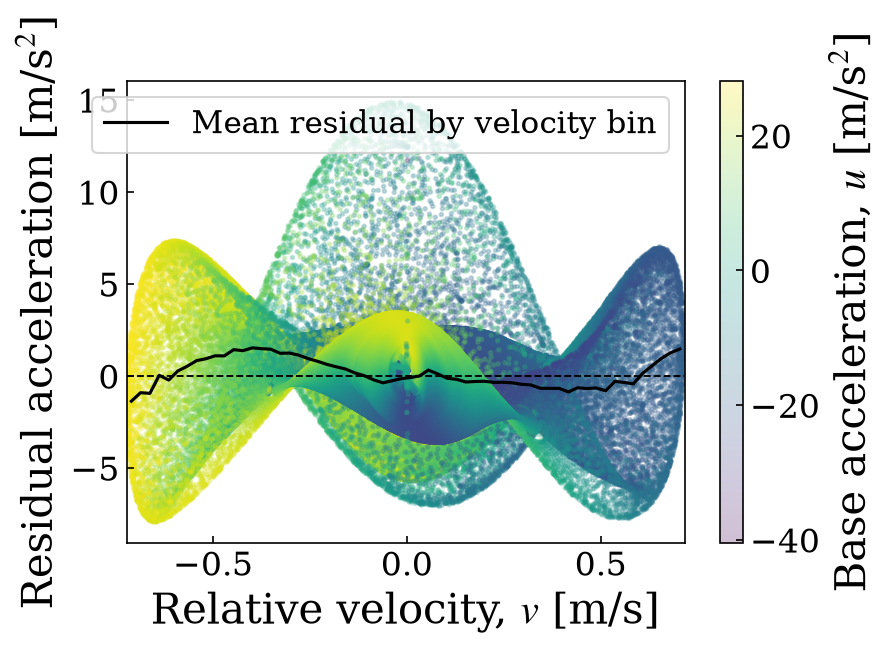

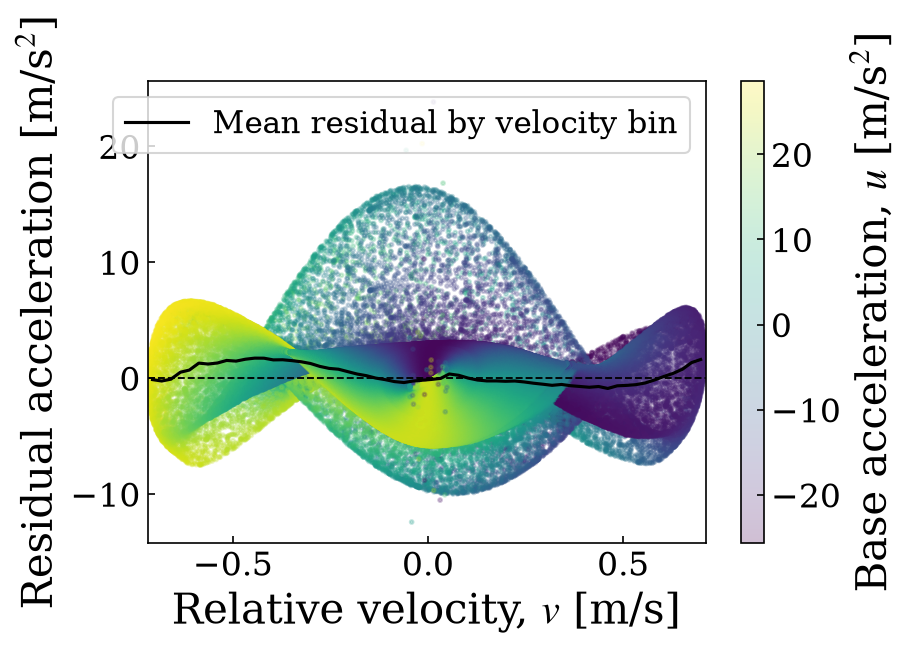

In [14]:
RESIDUAL_VELOCITY_BINS = 60
for signal in all_signals:
    t, x, v, u, a_measured = trajectory_arrays(signal)
    residual = a_measured - predicted_acceleration[signal["name"]]
    velocity_edges = np.linspace(np.min(v), np.max(v), RESIDUAL_VELOCITY_BINS + 1)
    velocity_bin = np.digitize(v, velocity_edges[1:-1])
    mean_velocity, mean_residual = [], []
    for bin_index in range(RESIDUAL_VELOCITY_BINS):
        bin_mask = velocity_bin == bin_index
        if np.count_nonzero(bin_mask) >= 20:
            mean_velocity.append(np.mean(v[bin_mask]))
            mean_residual.append(np.mean(residual[bin_mask]))
    fig, ax = plt.subplots()
    scatter = ax.scatter(v, residual, c=u, cmap="viridis", s=3, alpha=0.25, rasterized=True)
    ax.plot(mean_velocity, mean_residual, color="k", linewidth=1.5, label="Mean residual by velocity bin")
    ax.axhline(0.0, color="k", linestyle="--", linewidth=0.9)
    ax.set_xlabel("Relative velocity, $v$ [m/s]")
    ax.set_ylabel("Residual acceleration [m/s$^2$]")
    ax.legend()
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Base acceleration, $u$ [m/s$^2$]")
    fig.savefig(FIGURES_DIR / f"least_squares_residual_vs_velocity_colored_u_{slug(signal['name'])}.pdf", format="pdf")
    plt.show()
    plt.close(fig)

## Term contributions


C:\Users\bruno\AppData\Local\Temp\ipykernel_25596\4073326439.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(FIGURES_DIR / f"least_squares_term_contributions_{slug(signal['name'])}.pdf", format="pdf")


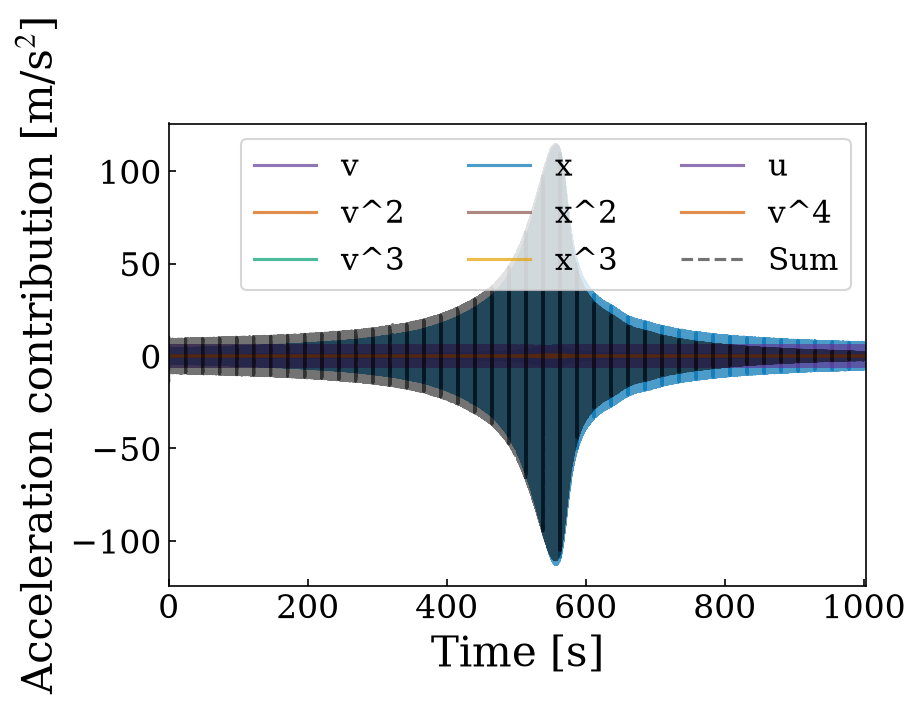

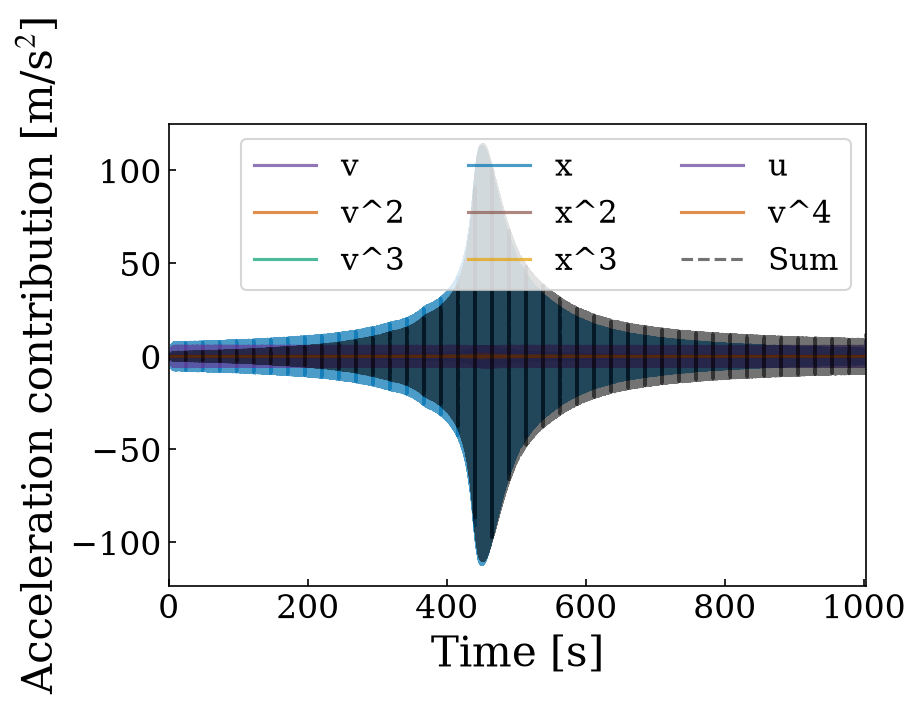

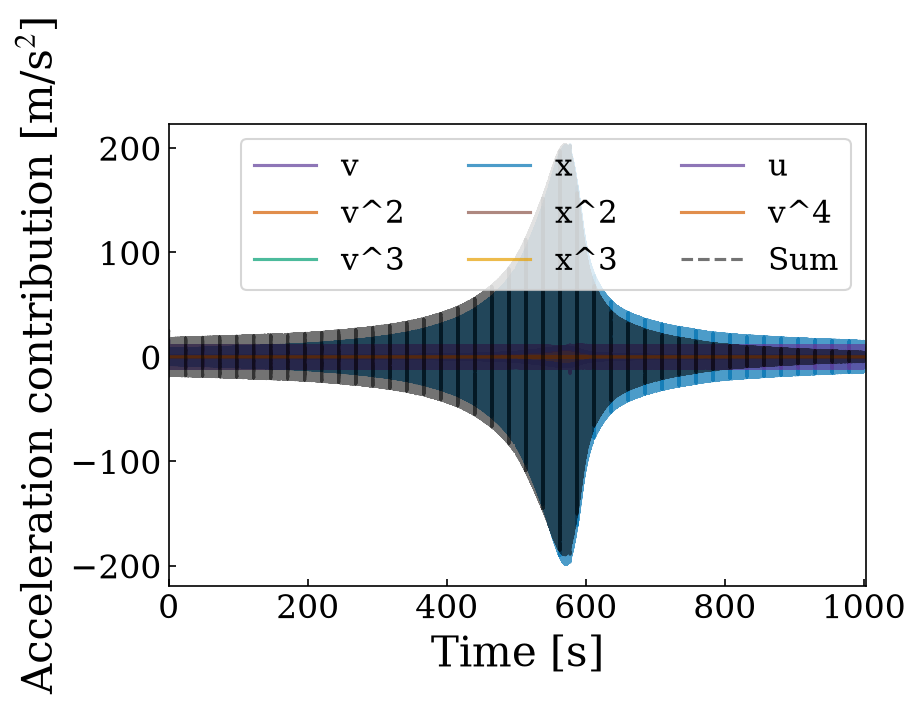

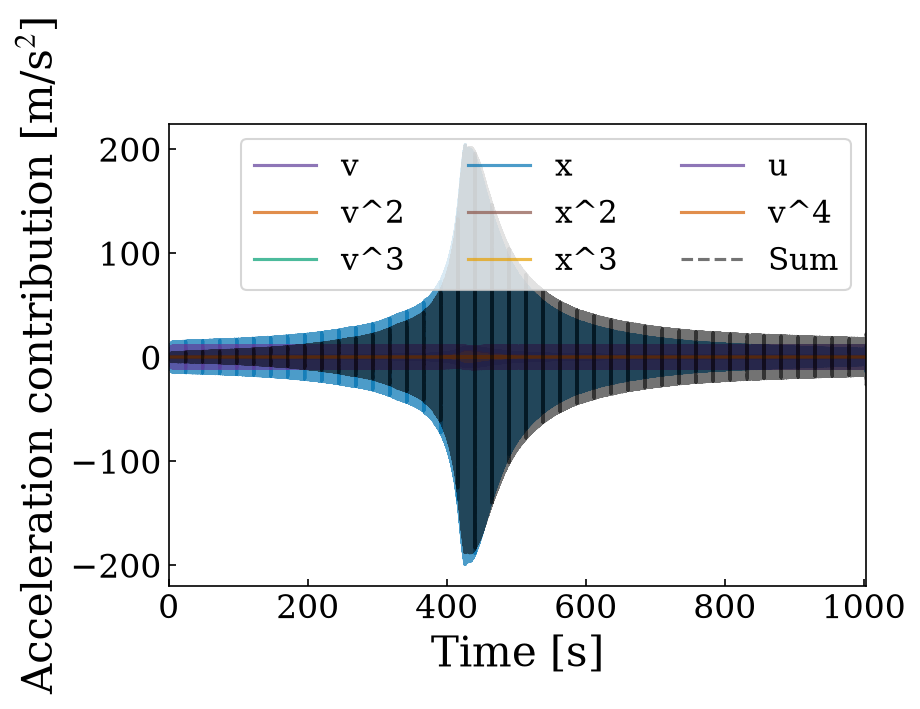

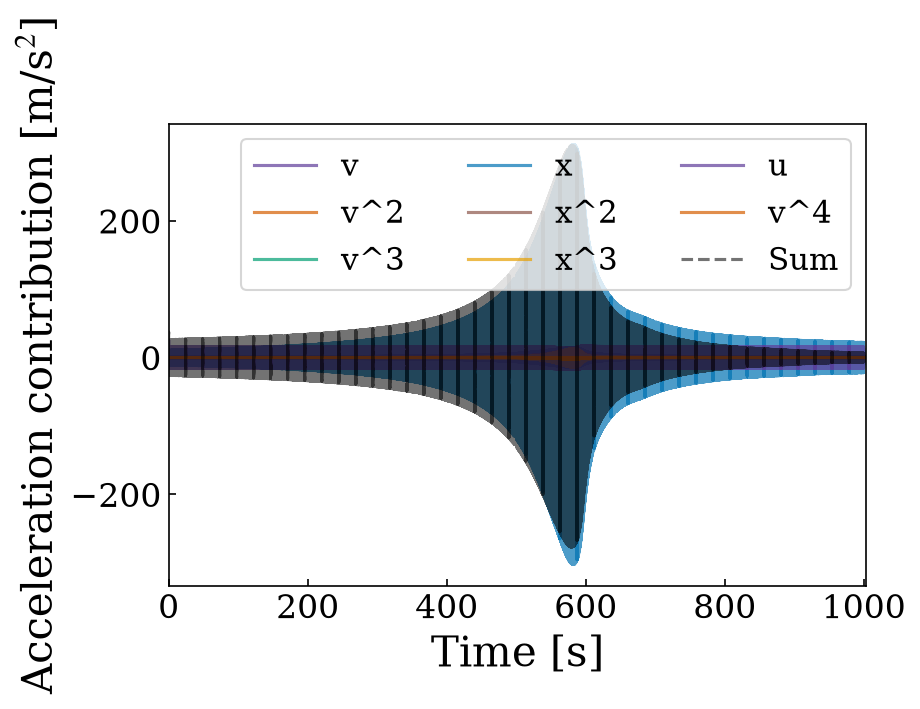

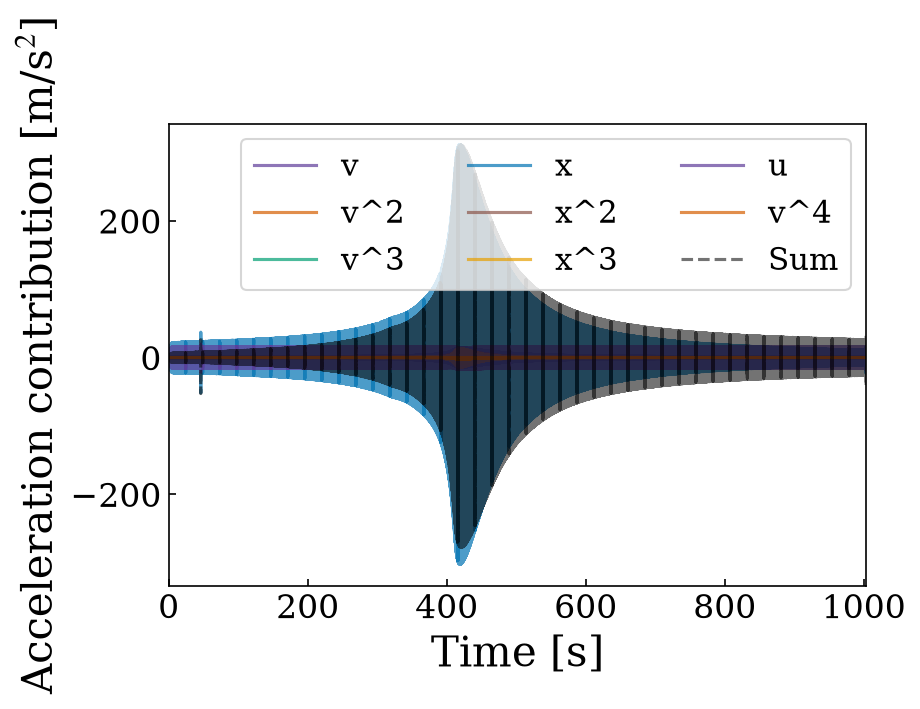

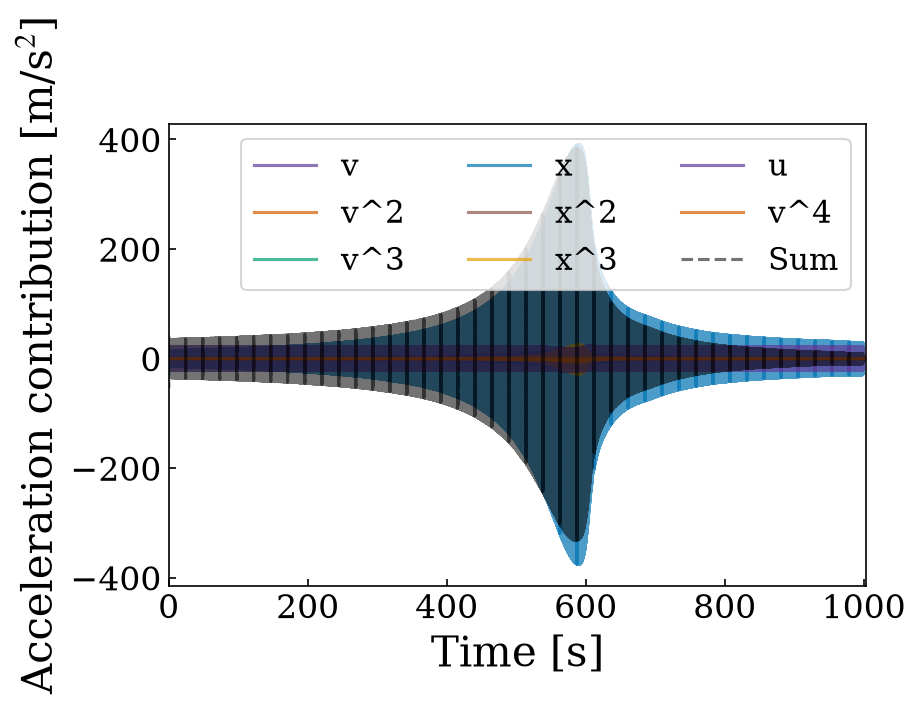

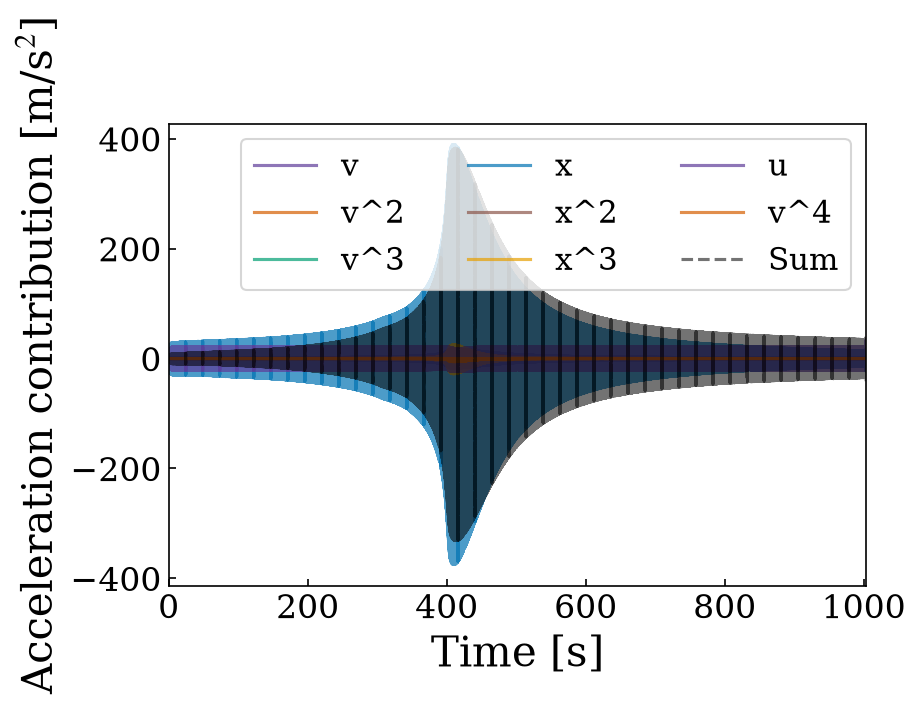

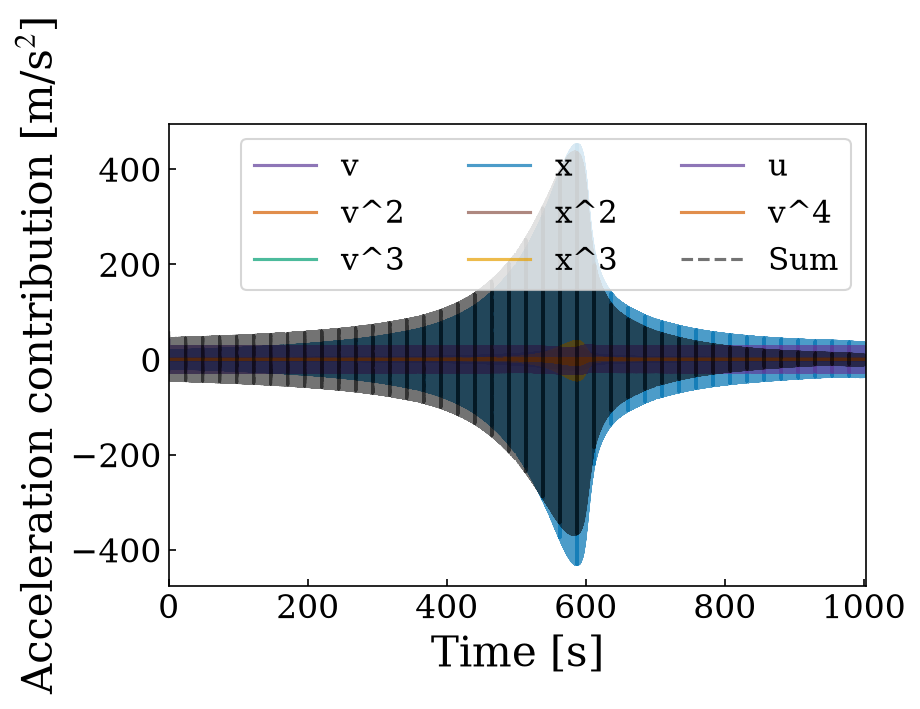

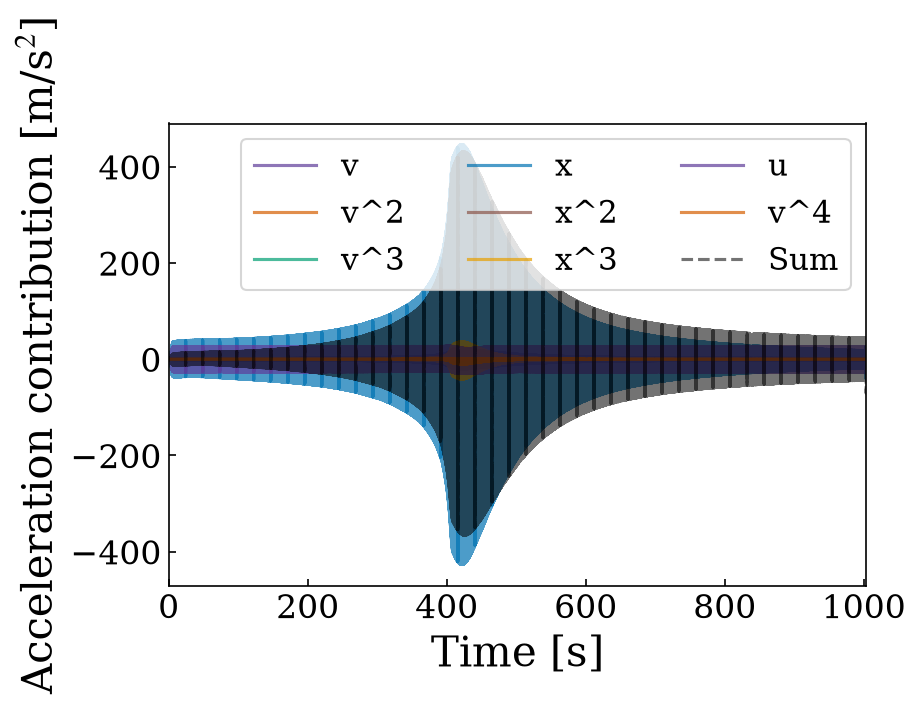

In [15]:
for signal in all_signals:
    t, x, v, u, a_measured = trajectory_arrays(signal)
    contributions = build_library(x, v, u) * coefficients
    a_predicted = np.sum(contributions, axis=1)
    relative_time = t - t[0]
    fig, ax = plt.subplots()
    for column, term_name in enumerate(TERM_NAMES):
        ax.plot(relative_time, contributions[:, column], label=term_name, alpha=0.7, rasterized=True)
    ax.plot(relative_time, a_predicted, color="k", linestyle="--", linewidth=1.5, alpha=0.55, label="Sum", rasterized=True)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Acceleration contribution [m/s$^2$]")
    ax.legend(ncol=3)
    fig.savefig(FIGURES_DIR / f"least_squares_term_contributions_{slug(signal['name'])}.pdf", format="pdf")
    plt.show()
    plt.close(fig)

## Dimensionless tip acceleration (3D)


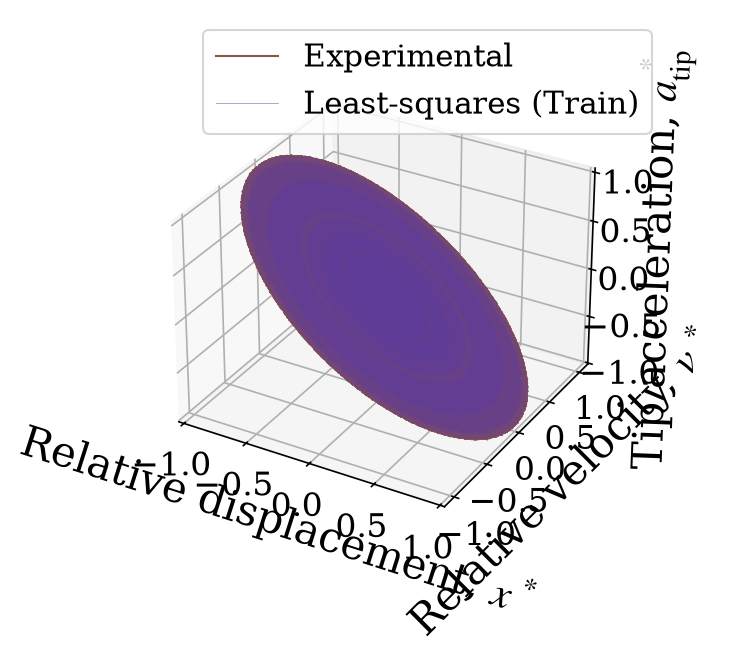

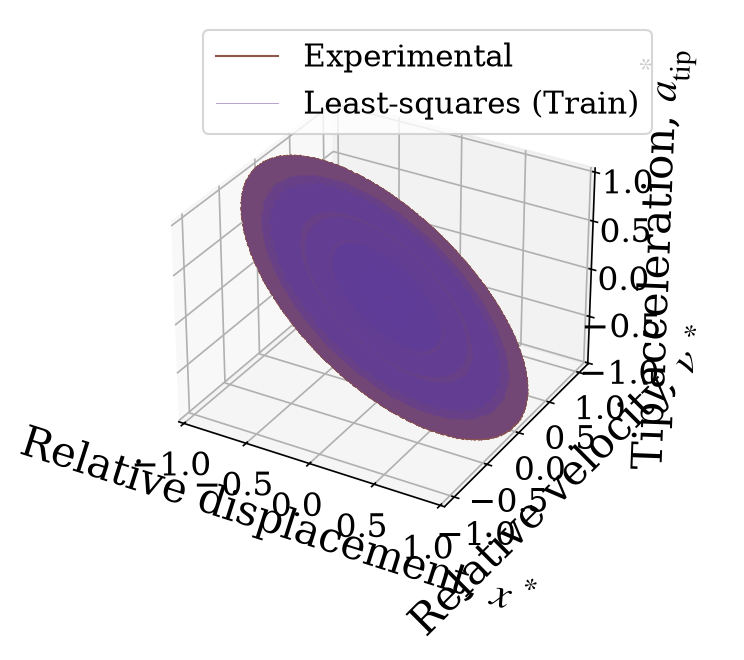

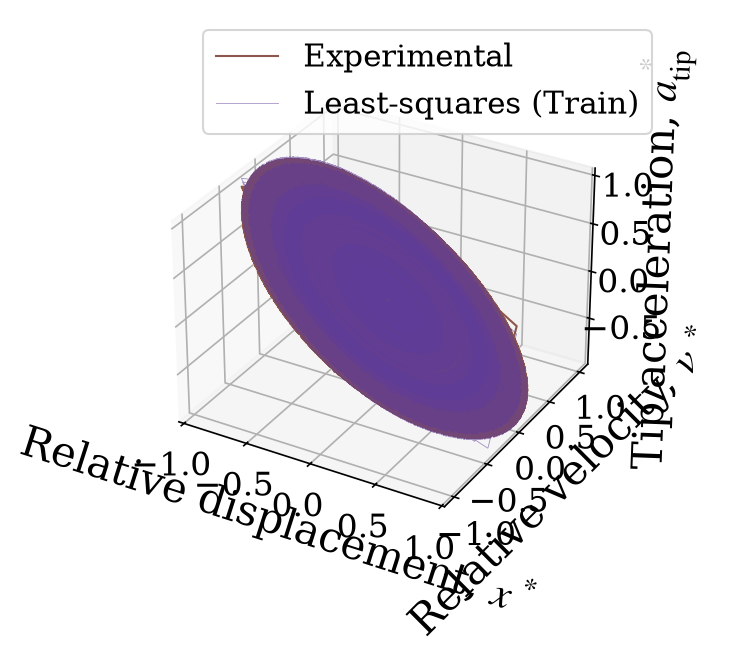

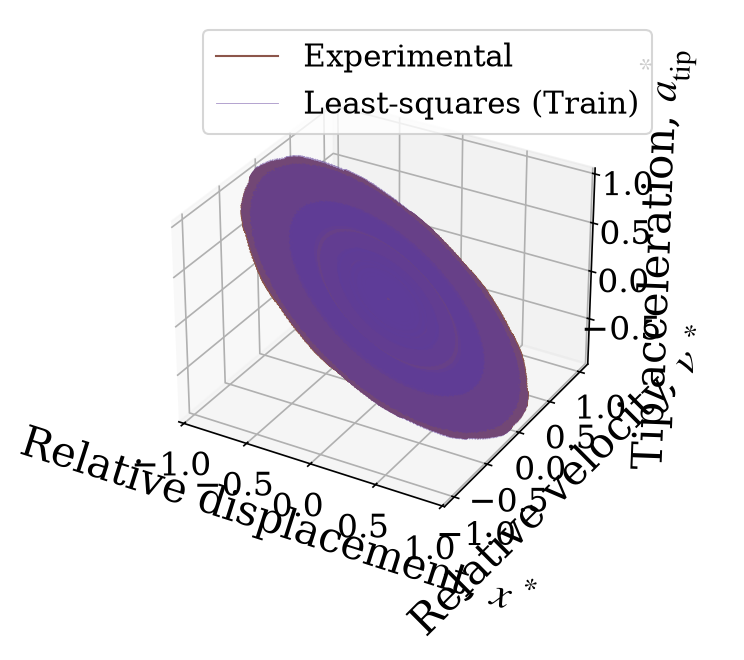

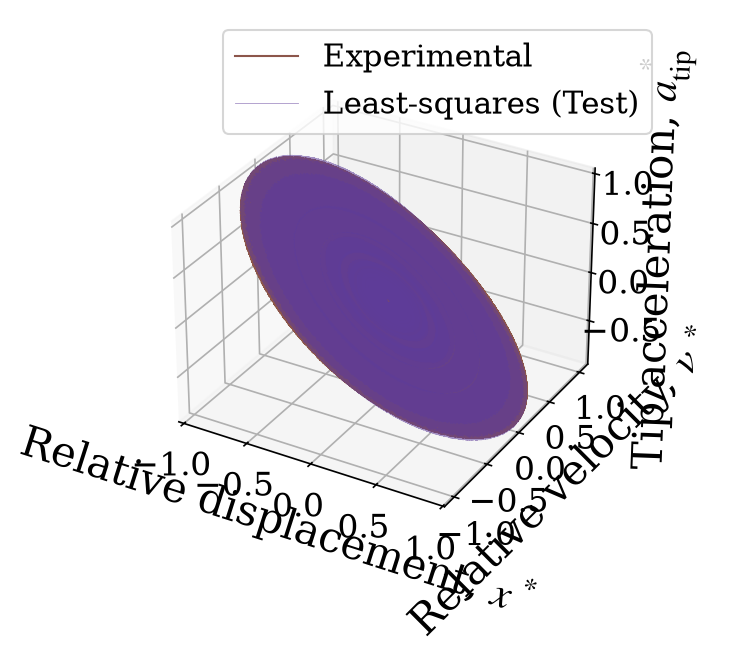

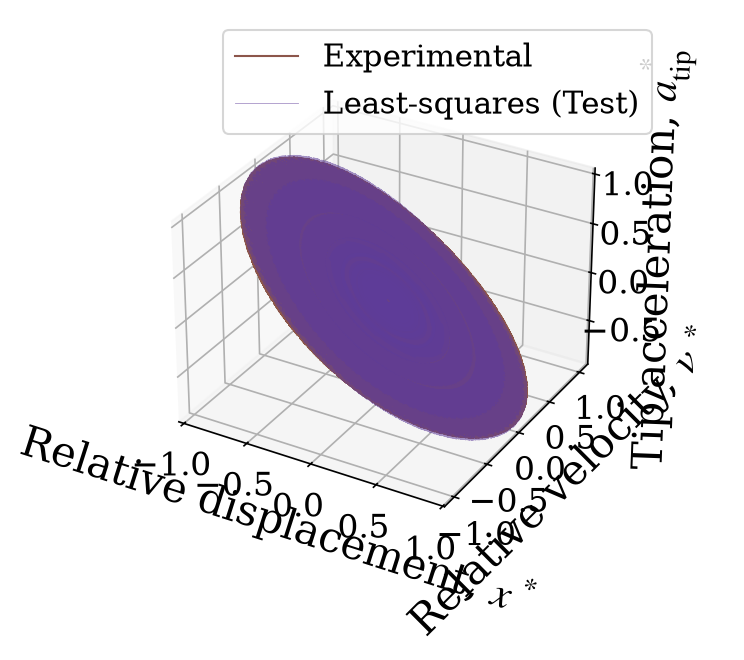

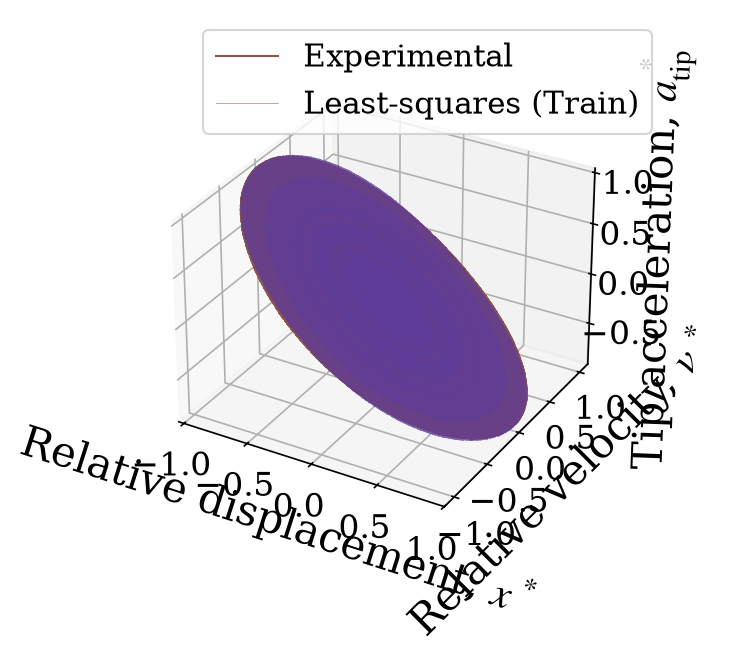

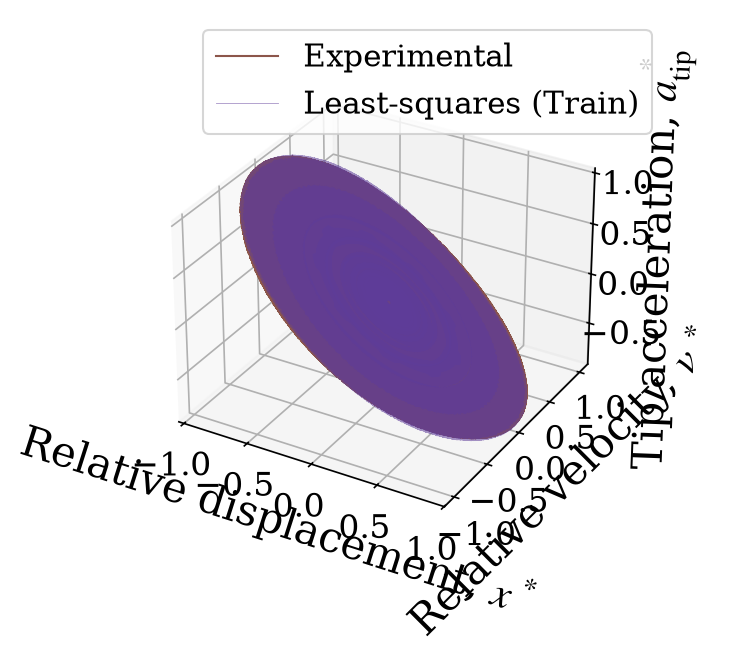

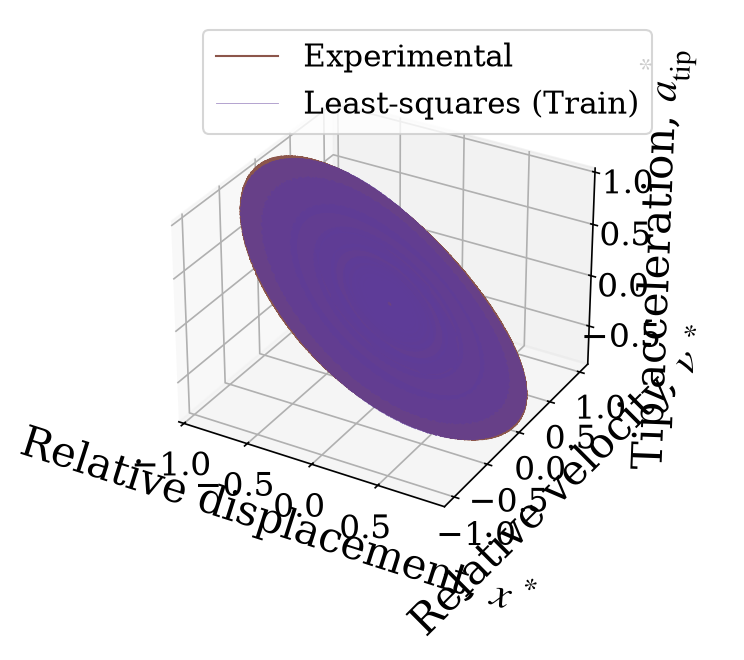

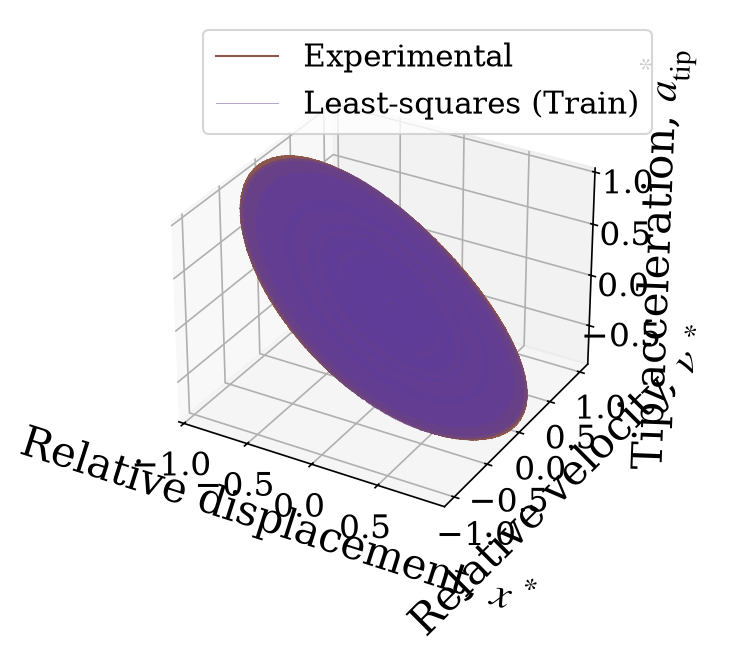

,signal,level_mg,sweep,total_points,damping_points,stiffness_points,x_scale,v_scale,a_tip_scale
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,401408,3577,3574,0.000321,0.189972,114.451186
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,401408,3754,3858,0.000319,0.189109,114.030043
2,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,401377,3853,3738,0.000574,0.331586,199.397097
3,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,401376,3381,3252,0.000577,0.333618,201.983619
4,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,401377,4065,3912,0.000881,0.502006,304.568616
5,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,up,401376,3376,3259,0.000881,0.501587,303.651295
6,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,down,401408,4274,4065,0.001105,0.622534,379.813275
7,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,up,401408,3139,2843,0.001101,0.620355,378.019637
8,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,down,401377,3013,2918,0.001277,0.722569,448.581714
9,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,up,401376,3743,3596,0.001261,0.718249,445.655088


In [16]:
dimensionless_scales = {}
dimensionless_diagnostics = []
for signal in all_signals:
    signal_name = signal["name"]
    t, measured_x, measured_v, measured_u, measured_a_rel = trajectory_arrays(signal)
    predicted_a_rel = predicted_acceleration[signal_name]
    measured_a_tip = measured_a_rel + measured_u
    predicted_a_tip = predicted_a_rel + measured_u
    x_scale = max(np.max(np.abs(measured_x)), np.finfo(float).eps)
    v_scale = max(np.max(np.abs(measured_v)), np.finfo(float).eps)
    a_tip_scale = max(np.max(np.abs(measured_a_tip)), np.finfo(float).eps)
    measured_x_star = measured_x / x_scale
    measured_v_star = measured_v / v_scale
    measured_a_tip_star = measured_a_tip / a_tip_scale
    predicted_a_tip_star = predicted_a_tip / a_tip_scale
    damping_mask = np.abs(measured_x_star) <= DIMENSIONLESS_ZERO_TOLERANCE
    stiffness_mask = np.abs(measured_v_star) <= DIMENSIONLESS_ZERO_TOLERANCE
    dimensionless_scales[signal_name] = {
        "x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": a_tip_scale,
        "normalization": "maximum absolute experimental value",
        "comparison_points": len(measured_x),
        "dimensionless_zero_tolerance": DIMENSIONLESS_ZERO_TOLERANCE,
        "damping_points": int(np.count_nonzero(damping_mask)),
        "stiffness_points": int(np.count_nonzero(stiffness_mask)),
    }
    dimensionless_diagnostics.append(
        {"signal": signal_name, "level_mg": excitation_level_mg(signal_name),
         "sweep": sweep_direction(signal_name), "total_points": len(measured_x),
         "damping_points": int(np.count_nonzero(damping_mask)),
         "stiffness_points": int(np.count_nonzero(stiffness_mask)),
         "x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": a_tip_scale}
    )
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_box_aspect(None, zoom=0.82)
    ax.plot(measured_x_star, measured_v_star, measured_a_tip_star, color=EXPERIMENTAL_COLOR,
            label="Experimental", linewidth=1.0, alpha=1.0)
    ax.plot(measured_x_star, measured_v_star, predicted_a_tip_star, color=LEAST_SQUARES_COLOR,
            label=f"Least-squares ({ROLE_LABELS[signal_role(signal_name)]})", linewidth=0.4, alpha=0.55)
    ax.set_xlabel("Relative displacement, $x^*$")
    ax.set_ylabel("Relative velocity, $v^*$")
    ax.set_zlabel("Tip acceleration, $a_{\\mathrm{tip}}^*$")
    ax.legend()
    fig.savefig(FIGURES_DIR / f"least_squares_dimensionless_tip_acceleration_3d_{slug(signal_name)}.pdf", format="pdf")
    plt.show()
    plt.close(fig)
dimensionless_diagnostics = pd.DataFrame(dimensionless_diagnostics)
display(dimensionless_diagnostics)

## Shared-protocol evaluation


,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Least squares,train,0.521702,0.024242,0.999412,0.021136,0.022068
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Least squares,train,0.531031,0.025560,0.999347,0.022665,0.023533
2,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Least squares,train,0.808973,0.020286,0.999588,0.019358,0.019636
3,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Least squares,train,0.716469,0.018688,0.999651,0.018104,0.018279
4,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,Least squares,test,1.374544,0.022897,0.999476,0.022441,0.022578
5,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,up,Least squares,test,1.548921,0.027049,0.999268,0.026900,0.026944
6,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,down,Least squares,train,1.801137,0.023200,0.999462,0.023080,0.023116
7,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,up,Least squares,train,1.986976,0.026633,0.999291,0.026967,0.026867
8,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,down,Least squares,train,2.028737,0.021671,0.999530,0.018551,0.019487
9,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,up,Least squares,train,2.053728,0.021832,0.999523,0.019188,0.019981


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,Least squares,2,802816,0.526387,0.024887,0.999381,0.021885,0.022785
1,1000,train,Least squares,2,802753,0.764122,0.019535,0.999618,0.018767,0.018998
2,1500,test,Least squares,2,802753,1.464331,0.024961,0.999377,0.024659,0.024749
3,2000,train,Least squares,2,802816,1.896335,0.024908,0.999380,0.025017,0.024984
4,2500,train,Least squares,2,802753,2.041271,0.021752,0.999527,0.018874,0.019737


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,Least squares,train,"(500, 1000, 2000, 2500)",8,3211138,1.468316,0.022806,0.999480,0.021307,0.021757
1,Least squares,test,"(1500,)",2,802753,1.464331,0.024961,0.999377,0.024659,0.024749


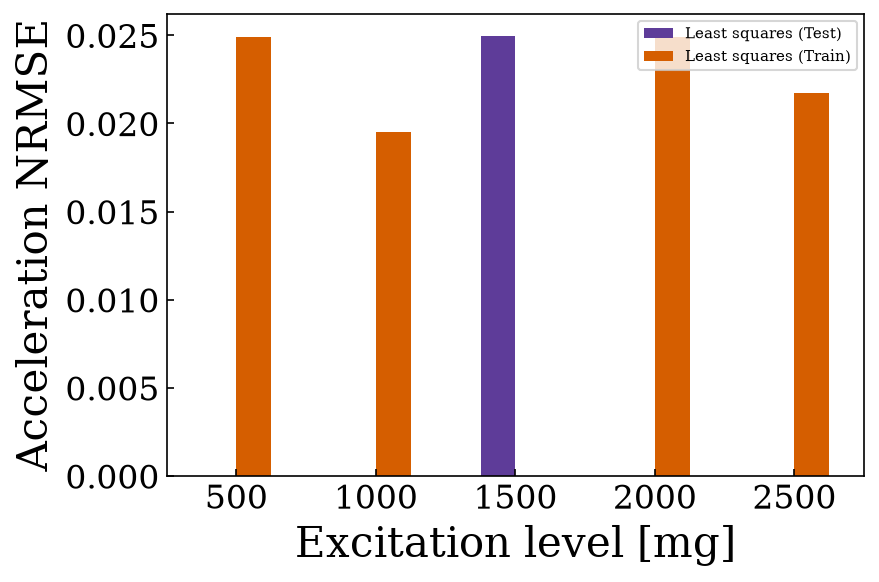

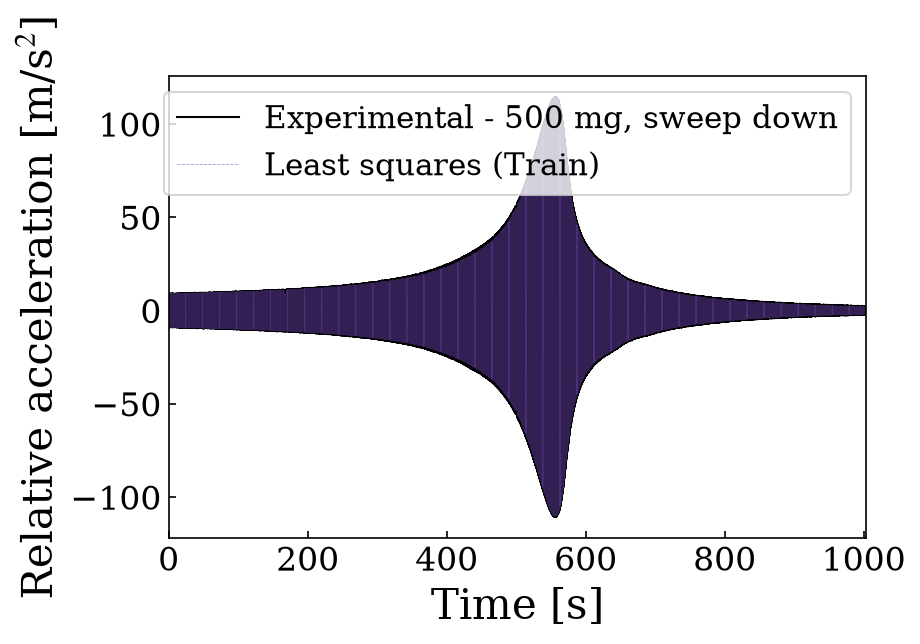

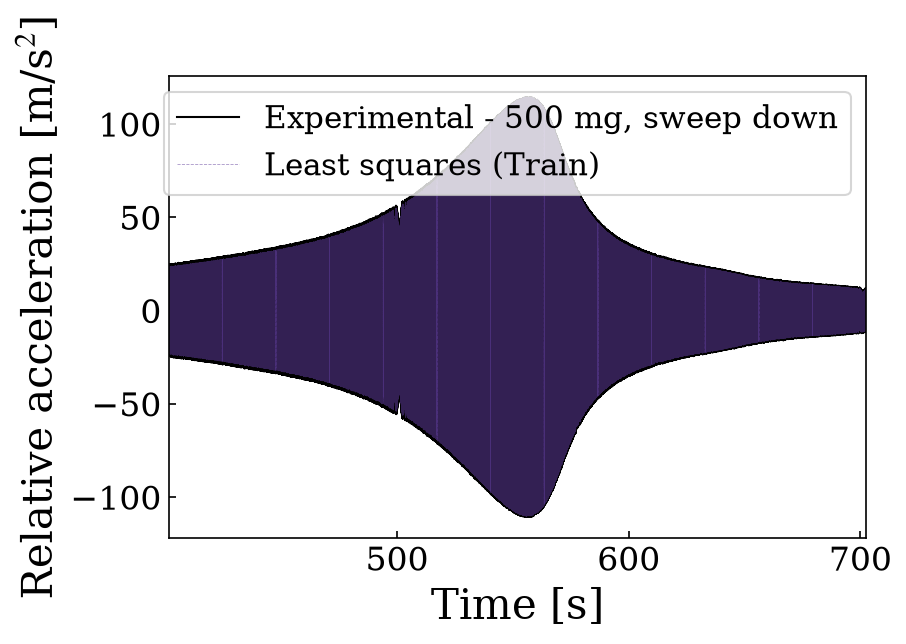

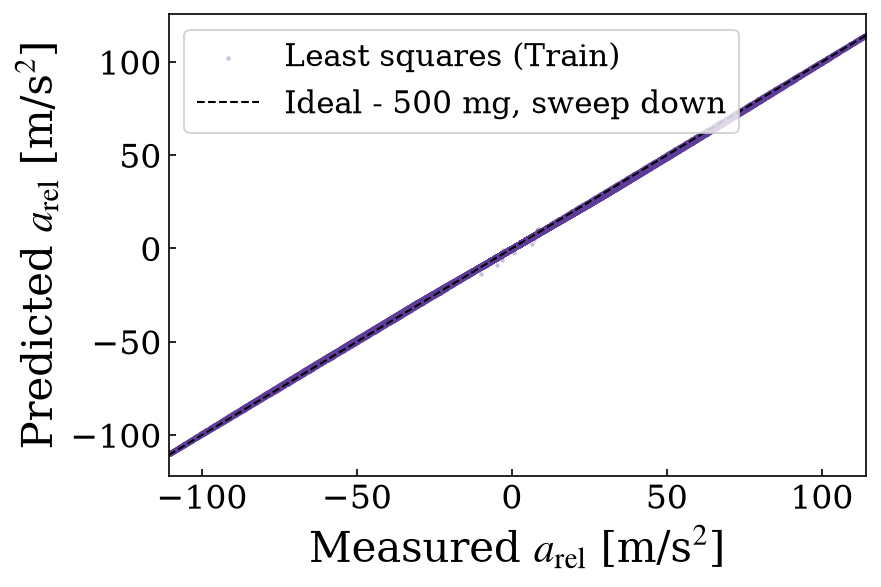

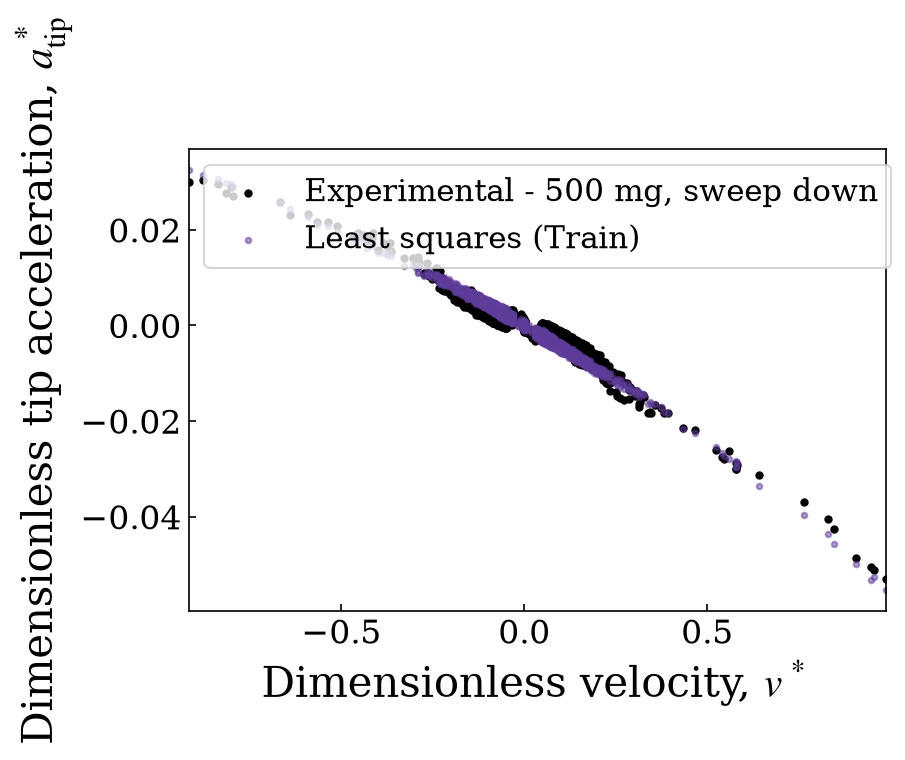

...

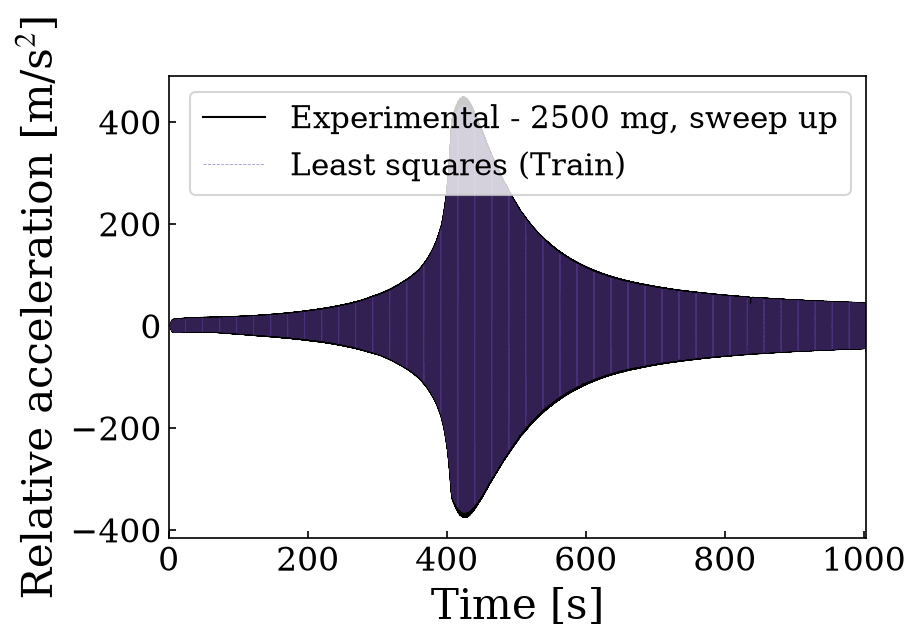

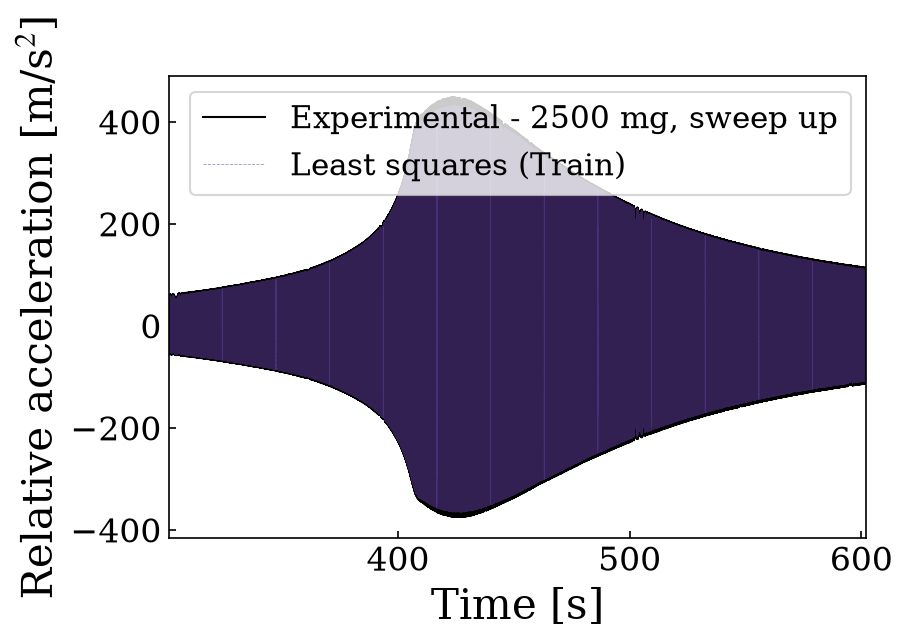

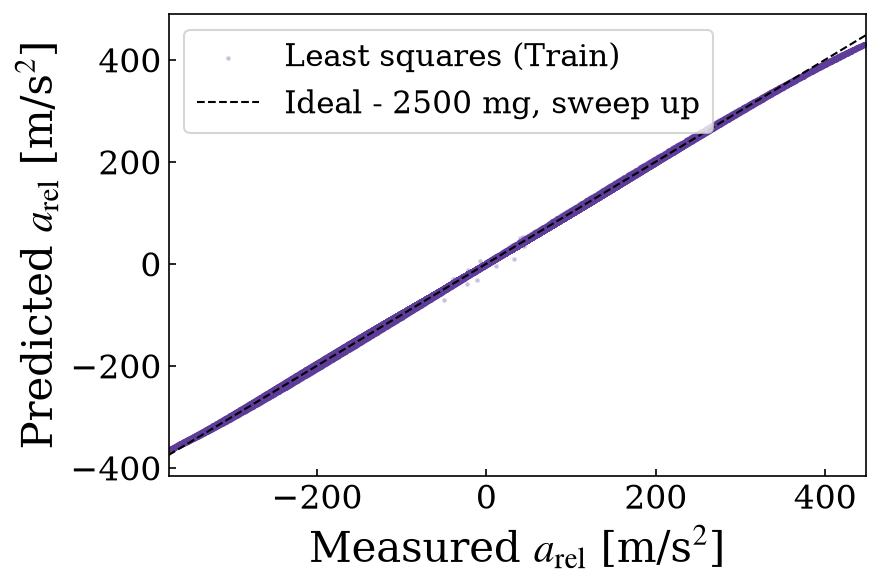

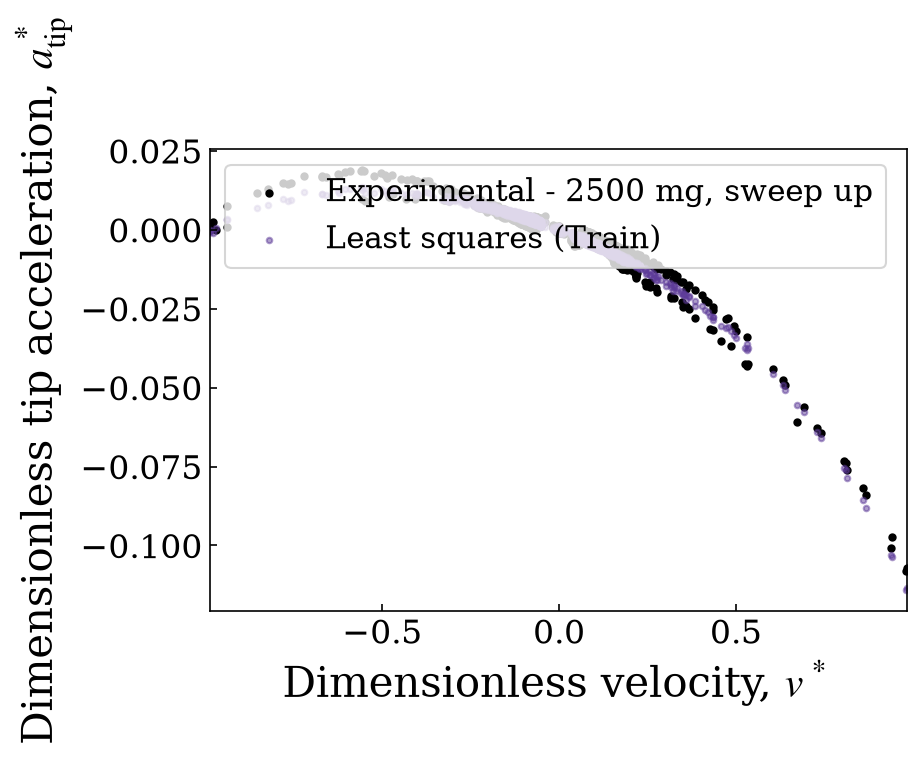

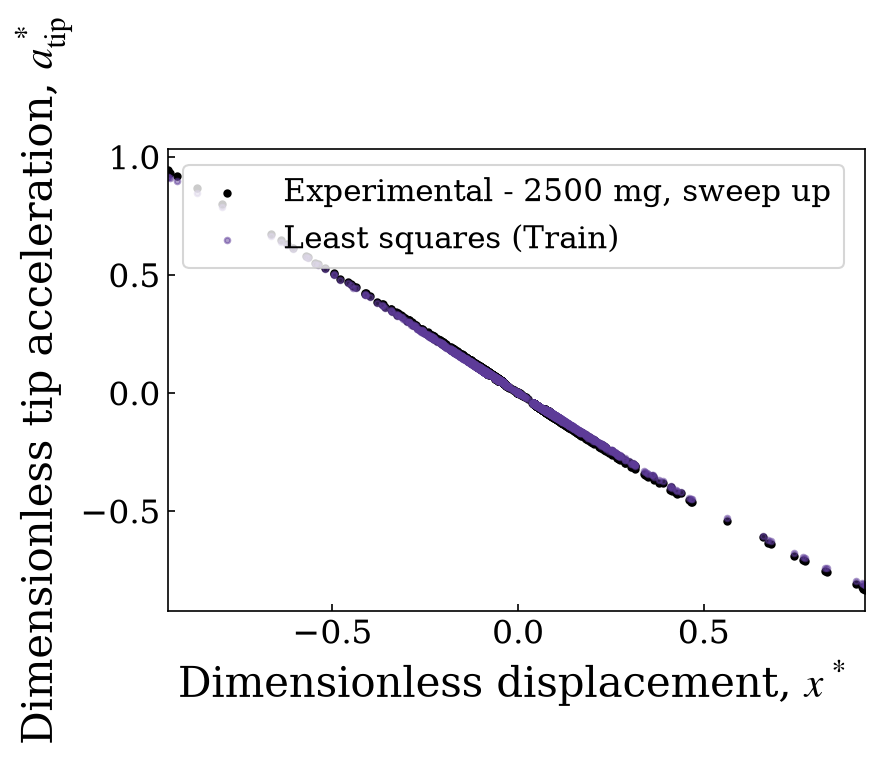

In [17]:
comparison_series = build_series(all_signals)
add_predictions(comparison_series, {"Least squares": model_acceleration})
split_metrics, split_per_level, split_aggregate = summarize_models(comparison_series)
display(split_metrics)
display(split_per_level)
display(split_aggregate)
plot_level_metrics(split_per_level, "total_NRMSE", "Acceleration NRMSE", FIGURES_DIR / "one_step_level_metrics.pdf")
split_dimensionless_scales = plot_diagnostics(comparison_series, FIGURES_DIR)

## Save results


In [20]:
least_squares_results = {
    "schema_version": 4,
    "source_prepared_file": str(PREPARED_FILE.resolve()),
    "protocol": {
        "levels_mg": LEVELS_MG,
        "test_level_mg": TEST_LEVEL_MG,
        "training_levels_mg": TRAINING_LEVELS_MG,
        "split": split_summary,
        "roles": ROLES,
        "description": PROTOCOL_DESCRIPTION,
    },
    "split_comparison": {
        "metrics": split_metrics,
        "per_level": split_per_level,
        "aggregate": split_aggregate,
        "dimensionless_scales": split_dimensionless_scales,
        "series": comparison_series,
    },
    "configuration": {
        "terms": TERM_NAMES,
        "all_samples_used": True,
        "dimensionless_zero_tolerance": DIMENSIONLESS_ZERO_TOLERANCE,
        "dimensionless_prediction_mode": "direct equation evaluation at measured x, v, u",
    },
    "coefficients": {term: float(c) for term, c in zip(TERM_NAMES, coefficients)},
    "training_samples": fit["samples"],
    "coefficient_table": coefficient_table.copy(),
    "equation_metrics": {"aggregate": metrics_table.copy(), "per_signal": per_signal_equation_metrics.copy()},
    "dimensionless_scales": dimensionless_scales,
    "dimensionless_diagnostics": dimensionless_diagnostics.copy(),
}
results_file = RESULTS_DIR / "least_squares_results.pkl"
with results_file.open("wb") as file:
    pickle.dump(least_squares_results, file, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:")
print(" -", results_file)

Saved:
 - C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\least_squares_results.pkl


## Summary


In [19]:
print("=" * 70)
print("LEAST-SQUARES MODEL")
print("=" * 70)
print("\nExcitation levels [mg]:", LEVELS_MG)
print("Protocol:", PROTOCOL_DESCRIPTION)
print(f"\nSamples in the fit: {fit['samples']:,}")
print("\nEquation (training levels):")
print("a_rel = " + " + ".join(f"({value:+.8e}) {term}" for term, value in zip(TERM_NAMES, coefficients)))
pooled = split_aggregate.set_index("role")
print("\nTrain NRMSE (pooled over the training levels):", f"{pooled.loc['train', 'total_NRMSE']:.6f}")
print(f"Test NRMSE ({TEST_LEVEL_MG} mg):", f"{pooled.loc['test', 'total_NRMSE']:.6f}")
print("Train R²:", f"{pooled.loc['train', 'total_R2']:.10f}")
print("Test R²:", f"{pooled.loc['test', 'total_R2']:.10f}")
print("\nFigures:", FIGURES_DIR.resolve())
print("Results:", RESULTS_DIR.resolve())

LEAST-SQUARES MODEL

Excitation levels [mg]: (500, 1000, 1500, 2000, 2500)
Protocol: single train/test split: test level 1500 mg; training levels (500, 1000, 2000, 2500) mg

Samples in the fit: 3,211,138

Equation (training levels):
a_rel = (-2.79683938e+01) v + (-3.22097607e+01) v^2 + (-1.98871351e+01) v^3 + (-3.53768961e+05) x + (+1.48264456e+07) x^2 + (+2.05888466e+10) x^3 + (-1.05726949e+00) u + (-3.73415236e+01) v^4

Train NRMSE (pooled over the training levels): 0.022806
Test NRMSE (1500 mg): 0.024961
Train R²: 0.9994798759
Test R²: 0.9993769505

Figures: C:\Users\bruno\Downloads\BEPE (2)\BEPE\figures\pipeline\3_least_squares
Results: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results
